# Tasks 4–7 Solo — Stranding, Aggregation, Portfolio, Sensitivity

Runs the full analysis pipeline on **two versions** in parallel:
- **Uniform**: group model — uniform η per fuel
- **Vintage**: solo extension — plant-level η_p (vintage-based thermal efficiency)

**Inputs:**
- `data/processed/gppd_eu_metrics.csv` — group model (uniform η)
- `data/processed/gppd_eu_metrics_solo.csv` — solo model (vintage η_p)
- `data/processed/ngfs_scenarios_elec.csv` — fuel prices EUR2024/MWh_elec (uniform)
- `data/processed/ngfs_scenarios.csv` — fuel prices EUR2024/MWh_th (vintage)
- `data/processed/ngfs_cf_evolution.csv` — CF trajectories by country/fuel/scenario/year

**Stranding definitions (all three computed):**
1. **Economic** (primary): π < 0 for K consecutive years
2. **Rule-based** (robustness): plant age > technical lifetime
3. **Utilisation** (robustness): CF < CF_threshold for K consecutive years

---

## Imports and configuration

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:,.3f}'.format)
plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.3, 'grid.linestyle': '--'})

# CONFIGURATION 
HORIZONS          = [2030, 2040, 2050]   
K                 = 3                    # consecutive-year threshold
CF_THRESHOLD      = 0.10                 # utilisation stranding CF threshold
TOP_N_COUNTRIES   = 10                   # countries shown in ranking plots
PRIMARY_STRANDING = 'stranded_eco'       # primary stranding definition for main figures
PRIMARY_VERSION   = 'uniform'            # version for main figures

# ────────────────────────────────────────────────────────────────
SCENARIOS = ['Net Zero 2050', 'Delayed transition', 'Current Policies']
SCENARIO_COLORS = {
    'Net Zero 2050'     : '#2166ac',
    'Delayed transition': '#d6604d',
    'Current Policies'  : '#4dac26',
}
SCENARIO_LABELS = {
    'Net Zero 2050'     : 'Net Zero 2050 (orderly)',
    'Delayed transition': 'Delayed Transition (disorderly)',
    'Current Policies'  : 'Current Policies (insufficient)',
}
FUEL_COLORS = {'coal': '#2c2c2c', 'gas': '#e07b39', 'oil': '#4a90d9'}
YEARS_ALL   = list(range(2020, 2051))

print(f"Configuration: HORIZONS={HORIZONS}, K={K}, CF_THRESHOLD={CF_THRESHOLD}")
print(f"Primary stranding: {PRIMARY_STRANDING} | Primary version: {PRIMARY_VERSION}")


Configuration: HORIZONS=[2030, 2040, 2050], K=3, CF_THRESHOLD=0.1
Primary stranding: stranded_eco | Primary version: uniform


## 1. Load all inputs

In [28]:
# Plant metrics
metrics_u = pd.read_csv('../../data/processed/gppd_eu_metrics.csv')
metrics_v = pd.read_csv('../../data/processed/gppd_eu_metrics_vintage.csv')

# NGFS prices
ngfs_elec = pd.read_csv('../../data/processed/ngfs_scenarios_elec.csv')
ngfs_th   = pd.read_csv('../../data/processed/ngfs_scenarios.csv')

# CF evolution
df_cf = pd.read_csv('../../data/processed/ngfs_cf_evolution.csv')

# Build lookup series
def price_series(df, var):
    return df[df['variable']==var].set_index(['scenario','year'])['value']

carbon_price = price_series(ngfs_th,   'Price|Carbon')
elec_price   = price_series(ngfs_elec, 'Price|Secondary Energy|Electricity')

fuel_price_elec = {
    f: price_series(ngfs_elec, f'Price|Primary Energy|{f.capitalize()}')
    for f in ['coal','gas','oil']
}
fuel_price_th = {
    f: price_series(ngfs_th, f'Price|Primary Energy|{f.capitalize()}')
    for f in ['coal','gas','oil']
}

# CF lookup: dict (country, fuel, scenario, year) → cf
cf_lookup = df_cf.set_index(['country','fuel','scenario','year'])['cf'].to_dict()

# ── Committed-emissions pre-computations (for rule-based stranding) ────────────
# Source: Pfeiffer et al. (2016) Applied Energy 179; Tong et al. (2019) Nature 572
#
# 1. Remaining carbon budget B_{s,t}: sum of NGFS allowed electricity-sector
#    emissions from year t to 2050 (tCO2). Represents how much CO2 the scenario
#    still allows from this point onward.
#    Unit: tCO2/yr in NGFS → already converted by Task 2 (×1e6 from MtCO2).
ngfs_emissions = (
    ngfs_th[ngfs_th['variable'] == 'Emissions|CO2|Energy|Supply|Electricity']
    [['scenario','year','value']].copy()
)
# Clamp negative values (NGFS can show negative net emissions under CCS)
ngfs_emissions['value'] = ngfs_emissions['value'].clip(lower=0)

# Reverse cumulative sum: B_{s,t} = sum_{tau=t}^{2050} E_{s,tau}
budget_lookup = {}
for scenario, grp in ngfs_emissions.groupby('scenario'):
    grp_sorted = grp.sort_values('year').set_index('year')['value']
    # Total emissions in each year (tCO2/yr), sum from each year to 2050
    for yr in YEARS_ALL:
        budget_lookup[(scenario, yr)] = float(
            grp_sorted[grp_sorted.index >= yr].sum()
        )

# 2. CF cumulative sum: cf_cumsum[(country,fuel,scenario,year)] = sum_{tau=2020}^{year} CF
#    Used to compute integral of CF over a time window efficiently.
cf_cumsum_lookup = {}
for (country, fuel, scenario), grp in df_cf.groupby(['country','fuel','scenario']):
    grp_sorted = grp.sort_values('year').set_index('year')['cf']
    cumsum = grp_sorted.cumsum()
    for yr in YEARS_ALL:
        cf_cumsum_lookup[(country, fuel, scenario, yr)] = float(cumsum.get(yr, 0.0))

# 3. Total active capacity per (scenario, year) — denominator for per-MW budget
#    Active = plant still within technical lifetime at that year
#    Computed on-the-fly in compute_stranding using the metrics dataframe.

print(f"metrics_u : {metrics_u.shape}")
print(f"metrics_v : {metrics_v.shape}")
print(f"CF lookup entries      : {len(cf_lookup):,}")
print(f"Budget lookup entries  : {len(budget_lookup):,}")
print(f"CF cumsum entries      : {len(cf_cumsum_lookup):,}")
print()
print("Remaining budget B_{s,t} (tCO2) at key years:")
for scenario in SCENARIOS:
    vals = [f"{budget_lookup.get((scenario, yr), 0)/1e9:.2f}Gt" for yr in [2020, 2030, 2040, 2050]]
    print(f"  {scenario:32s}: {vals}")
print()
print(f"Carbon price 2030/2040/2050 — Net Zero 2050: "
      f"{carbon_price.get(('Net Zero 2050',2030),float('nan')):.0f} / "
      f"{carbon_price.get(('Net Zero 2050',2040),float('nan')):.0f} / "
      f"{carbon_price.get(('Net Zero 2050',2050),float('nan')):.0f} EUR2024/tCO2")


metrics_u : (824, 15)
metrics_v : (824, 19)
CF lookup entries      : 5,580
Budget lookup entries  : 93
CF cumsum entries      : 5,580

Remaining budget B_{s,t} (tCO2) at key years:
  Net Zero 2050                   : ['4.95Gt', '0.22Gt', '0.00Gt', '0.00Gt']
  Delayed transition              : ['6.50Gt', '1.18Gt', '0.02Gt', '0.00Gt']
  Current Policies                : ['6.80Gt', '1.48Gt', '0.24Gt', '0.02Gt']

Carbon price 2030/2040/2050 — Net Zero 2050: 377 / 946 / 1386 EUR2024/tCO2


## Task 4 — Plant Profitability Model and Stranding Flags

### Profitability equation
$$\pi_{p,t,s} = P_{t,s} - C^{\text{fuel}}_{p,t,s} - C^{\text{O\&M}}_p - C^{\text{CO}_2}_{p,t,s}$$

**Uniform:** fuel cost = `fuel_price_elec` (pre-divided by η_fuel in group Task 3); CO2 cost = carbon × ε_uniform  
**Vintage:** fuel cost = `fuel_price_th` / η_p (plant-level); CO2 cost = carbon × ε_vintage

### Stranding definitions
1. **Economic** (primary): π < 0 for K consecutive years (irreversible once triggered)
2. **Rule-based** (Pfeiffer et al., 2016; Tong et al., 2019): committed-emissions approach  
   A plant is stranded if its **remaining committed emissions** exceed its proportional share  
   of the scenario's remaining carbon budget — *without hardcoding any phase-out year*.  
   
   $$CE_{p,t,s} = \varepsilon_p \times MW_p \times 8760 \times \sum_{\tau=t}^{\min(2050,\,\text{comm}+\text{lt})} CF_{c,f,\tau,s}$$
   
   $$B_{s,t} = \sum_{\tau=t}^{2050} E^{\text{NGFS}}_{s,\tau} \quad \text{(remaining scenario budget)}$$
   
   Plant p is stranded at time t under s if it is still within its technical lifetime **and**:
   $$CE_{p,t,s} > B_{s,t} \times \frac{MW_p}{\sum_{q\,\text{active}} MW_q}$$
   
   This naturally gives near-zero stranding under Current Policies (large B) and  
   significant stranding under Net Zero 2050 (small B) — no scenario-specific hardcoding.  
   Irreversible once triggered (cummax).  
   **Sources:** Pfeiffer et al. (2016) *Applied Energy* 179:1395–1408;  
   Tong et al. (2019) *Nature* 572:373–377.

3. **Utilisation** (robustness): CF < CF_threshold for K consecutive years (irreversible)


In [29]:
def compute_stranding(metrics, version='uniform'):
    """
    Compute profit margins and three stranding flags for all plants × scenarios × years.
    Returns tidy DataFrame: one row per (gppd_idnr, scenario, year).

    stranded_rb: committed-emissions rule-based stranding (Pfeiffer et al., 2016).
      A plant is stranded if still within technical lifetime AND its committed
      emissions exceed its proportional share of the scenario's remaining
      carbon budget B_{s,t}. Irreversible once triggered.
    """
    # Pre-compute total active capacity per (scenario, year) for budget allocation
    # Active = plant still within its technical lifetime at that year
    total_active_mw = {}
    for scenario in SCENARIOS:
        for yr in YEARS_ALL:
            total_active_mw[(scenario, yr)] = float(
                metrics.apply(
                    lambda r: r['capacity_mw'] if yr <= int(r['commissioning_year']) + int(r['lifetime']) else 0.0,
                    axis=1
                ).sum()
            )

    rows = []
    for _, plant in metrics.iterrows():
        fuel    = plant['fuel']
        comm    = int(plant['commissioning_year'])
        lt      = int(plant['lifetime'])
        om      = plant['om_variable_eur2024_per_MWh']
        country = plant['country']
        cap_mw  = plant['capacity_mw']
        vintage = 'pre2000' if comm < 2000 else 'post2000'

        eps   = (plant['carbon_intensity_tCO2_per_MWh_elec']
                 if version == 'uniform' else plant['epsilon_vintage'])
        eta_p = (None if version == 'uniform' else plant['eta_vintage'])

        for scenario in SCENARIOS:
            margins, cfs = [], []
            for yr in YEARS_ALL:
                P_t   = elec_price.get((scenario, yr), float('nan'))
                C_co2 = carbon_price.get((scenario, yr), float('nan')) * eps
                C_f   = (fuel_price_elec[fuel].get((scenario, yr), float('nan')) if version == 'uniform'
                         else fuel_price_th[fuel].get((scenario, yr), float('nan')) / eta_p)
                margin = (P_t - C_f - om - C_co2
                          if not any(np.isnan(x) for x in [P_t, C_f, C_co2])
                          else float('nan'))
                margins.append(margin)
                cfs.append(cf_lookup.get((country, fuel, scenario, yr), 0.0))

            # ── Committed-emissions rule-based stranding ──────────────────────
            # CE_{p,t,s} = eps × MW × 8760 × integral_CF from t to min(2050, comm+lt)
            # Using pre-computed CF cumulative sums for efficiency.
            # cf_cumsum[(c,f,s,t)] = sum_{tau=2020}^{t} CF_{c,f,s,tau}
            # Integral from t to T = cf_cumsum(T) - cf_cumsum(t-1)
            end_yr = min(2050, comm + lt)  # natural retirement or 2050, whichever first
            rb_flags = []
            for yr in YEARS_ALL:
                within_life = (yr <= comm + lt)
                if not within_life:
                    # Past technical lifetime: natural retirement, not premature stranding
                    rb_flags.append(0)
                    continue
                # Integral of CF from yr to end_yr
                cf_int_to_end   = cf_cumsum_lookup.get((country, fuel, scenario, end_yr), 0.0)
                cf_int_before_t = cf_cumsum_lookup.get((country, fuel, scenario, yr - 1), 0.0) if yr > 2020 else 0.0
                cf_integral = max(0.0, cf_int_to_end - cf_int_before_t)

                # Plant's committed emissions (tCO2) from yr to end of technical life
                CE_plant = eps * cap_mw * 8760 * cf_integral

                # Scenario's remaining budget and per-MW proportional share
                B_st      = budget_lookup.get((scenario, yr), 0.0)
                tot_mw    = total_active_mw.get((scenario, yr), 1.0)
                B_plant   = B_st * (cap_mw / tot_mw) if tot_mw > 0 else 0.0

                # Stranded if committed emissions exceed proportional budget share
                rb_flags.append(int(CE_plant > B_plant))

            for i, yr in enumerate(YEARS_ALL):
                rows.append({
                    'gppd_idnr'  : plant['gppd_idnr'],
                    'country'    : country,
                    'fuel'       : fuel,
                    'capacity_mw': cap_mw,
                    'commissioning_year': comm,
                    'lifetime'   : lt,
                    'vintage'    : vintage,
                    'scenario'   : scenario,
                    'year'       : yr,
                    'margin'     : margins[i],
                    'cf_t'       : cfs[i],
                    'stranded_rb': rb_flags[i],
                })

    df = pd.DataFrame(rows)
    df = df.sort_values(['gppd_idnr','scenario','year']).reset_index(drop=True)

    # Economic stranding — K consecutive negative margins, irreversible
    df['neg_margin'] = (df['margin'] < 0).astype(float)
    df['neg_margin'] = df['neg_margin'].where(df['margin'].notna(), float('nan'))
    df['_consec_neg'] = (
        df.groupby(['gppd_idnr','scenario'])['neg_margin']
        .transform(lambda x: x.rolling(K, min_periods=K).sum())
    )
    df['_eco_raw'] = (df['_consec_neg'] == K).astype(int)
    df['stranded_eco'] = (
        df.groupby(['gppd_idnr','scenario'])['_eco_raw']
        .transform(lambda x: x.cummax())
    ).astype(int)

    # Rule-based stranding — make irreversible (once stranded, always stranded)
    df['stranded_rb'] = (
        df.groupby(['gppd_idnr','scenario'])['stranded_rb']
        .transform(lambda x: x.cummax())
    ).astype(int)

    # Utilisation stranding — K consecutive years CF < threshold, irreversible
    df['_low_cf'] = (df['cf_t'] < CF_THRESHOLD).astype(float)
    df['_consec_low'] = (
        df.groupby(['gppd_idnr','scenario'])['_low_cf']
        .transform(lambda x: x.rolling(K, min_periods=K).sum())
    )
    df['_util_raw'] = (df['_consec_low'] == K).astype(int)
    df['stranded_util'] = (
        df.groupby(['gppd_idnr','scenario'])['_util_raw']
        .transform(lambda x: x.cummax())
    ).astype(int)

    drop_cols = [c for c in df.columns if c.startswith('_')]
    return df.drop(columns=drop_cols)

print("Computing stranding — uniform version (committed-emissions rule-based)")
df_u = compute_stranding(metrics_u, version='uniform')
df_u.to_csv('../../data/processed/stranding_uniform.csv', index=False)
print(f"  stranding_uniform.csv  |  {df_u.shape}")

print("Computing stranding — vintage version")
df_v = compute_stranding(metrics_v, version='vintage')
df_v.to_csv('../../data/processed/stranding_vintage.csv', index=False)
print(f"  stranding_vintage.csv  |  {df_v.shape}")

# Quick validation: check stranded_rb varies by scenario 
print()
print("Validation — stranded_rb EU share at 2040 by scenario :")
for scenario in SCENARIOS:
    sub = df_u[(df_u['scenario'] == scenario) & (df_u['year'] == 2040)]
    share = np.average(sub['stranded_rb'], weights=sub['capacity_mw']) * 100
    print(f"  {scenario:32s}: {share:.1f}%")


Computing stranding — uniform version (committed-emissions rule-based)
  stranding_uniform.csv  |  (76632, 15)
Computing stranding — vintage version
  stranding_vintage.csv  |  (76632, 15)

Validation — stranded_rb EU share at 2040 by scenario :
  Net Zero 2050                   : 50.0%
  Delayed transition              : 13.0%
  Current Policies                : 9.6%


### 4.1 Validation — margin distributions at selected horizons

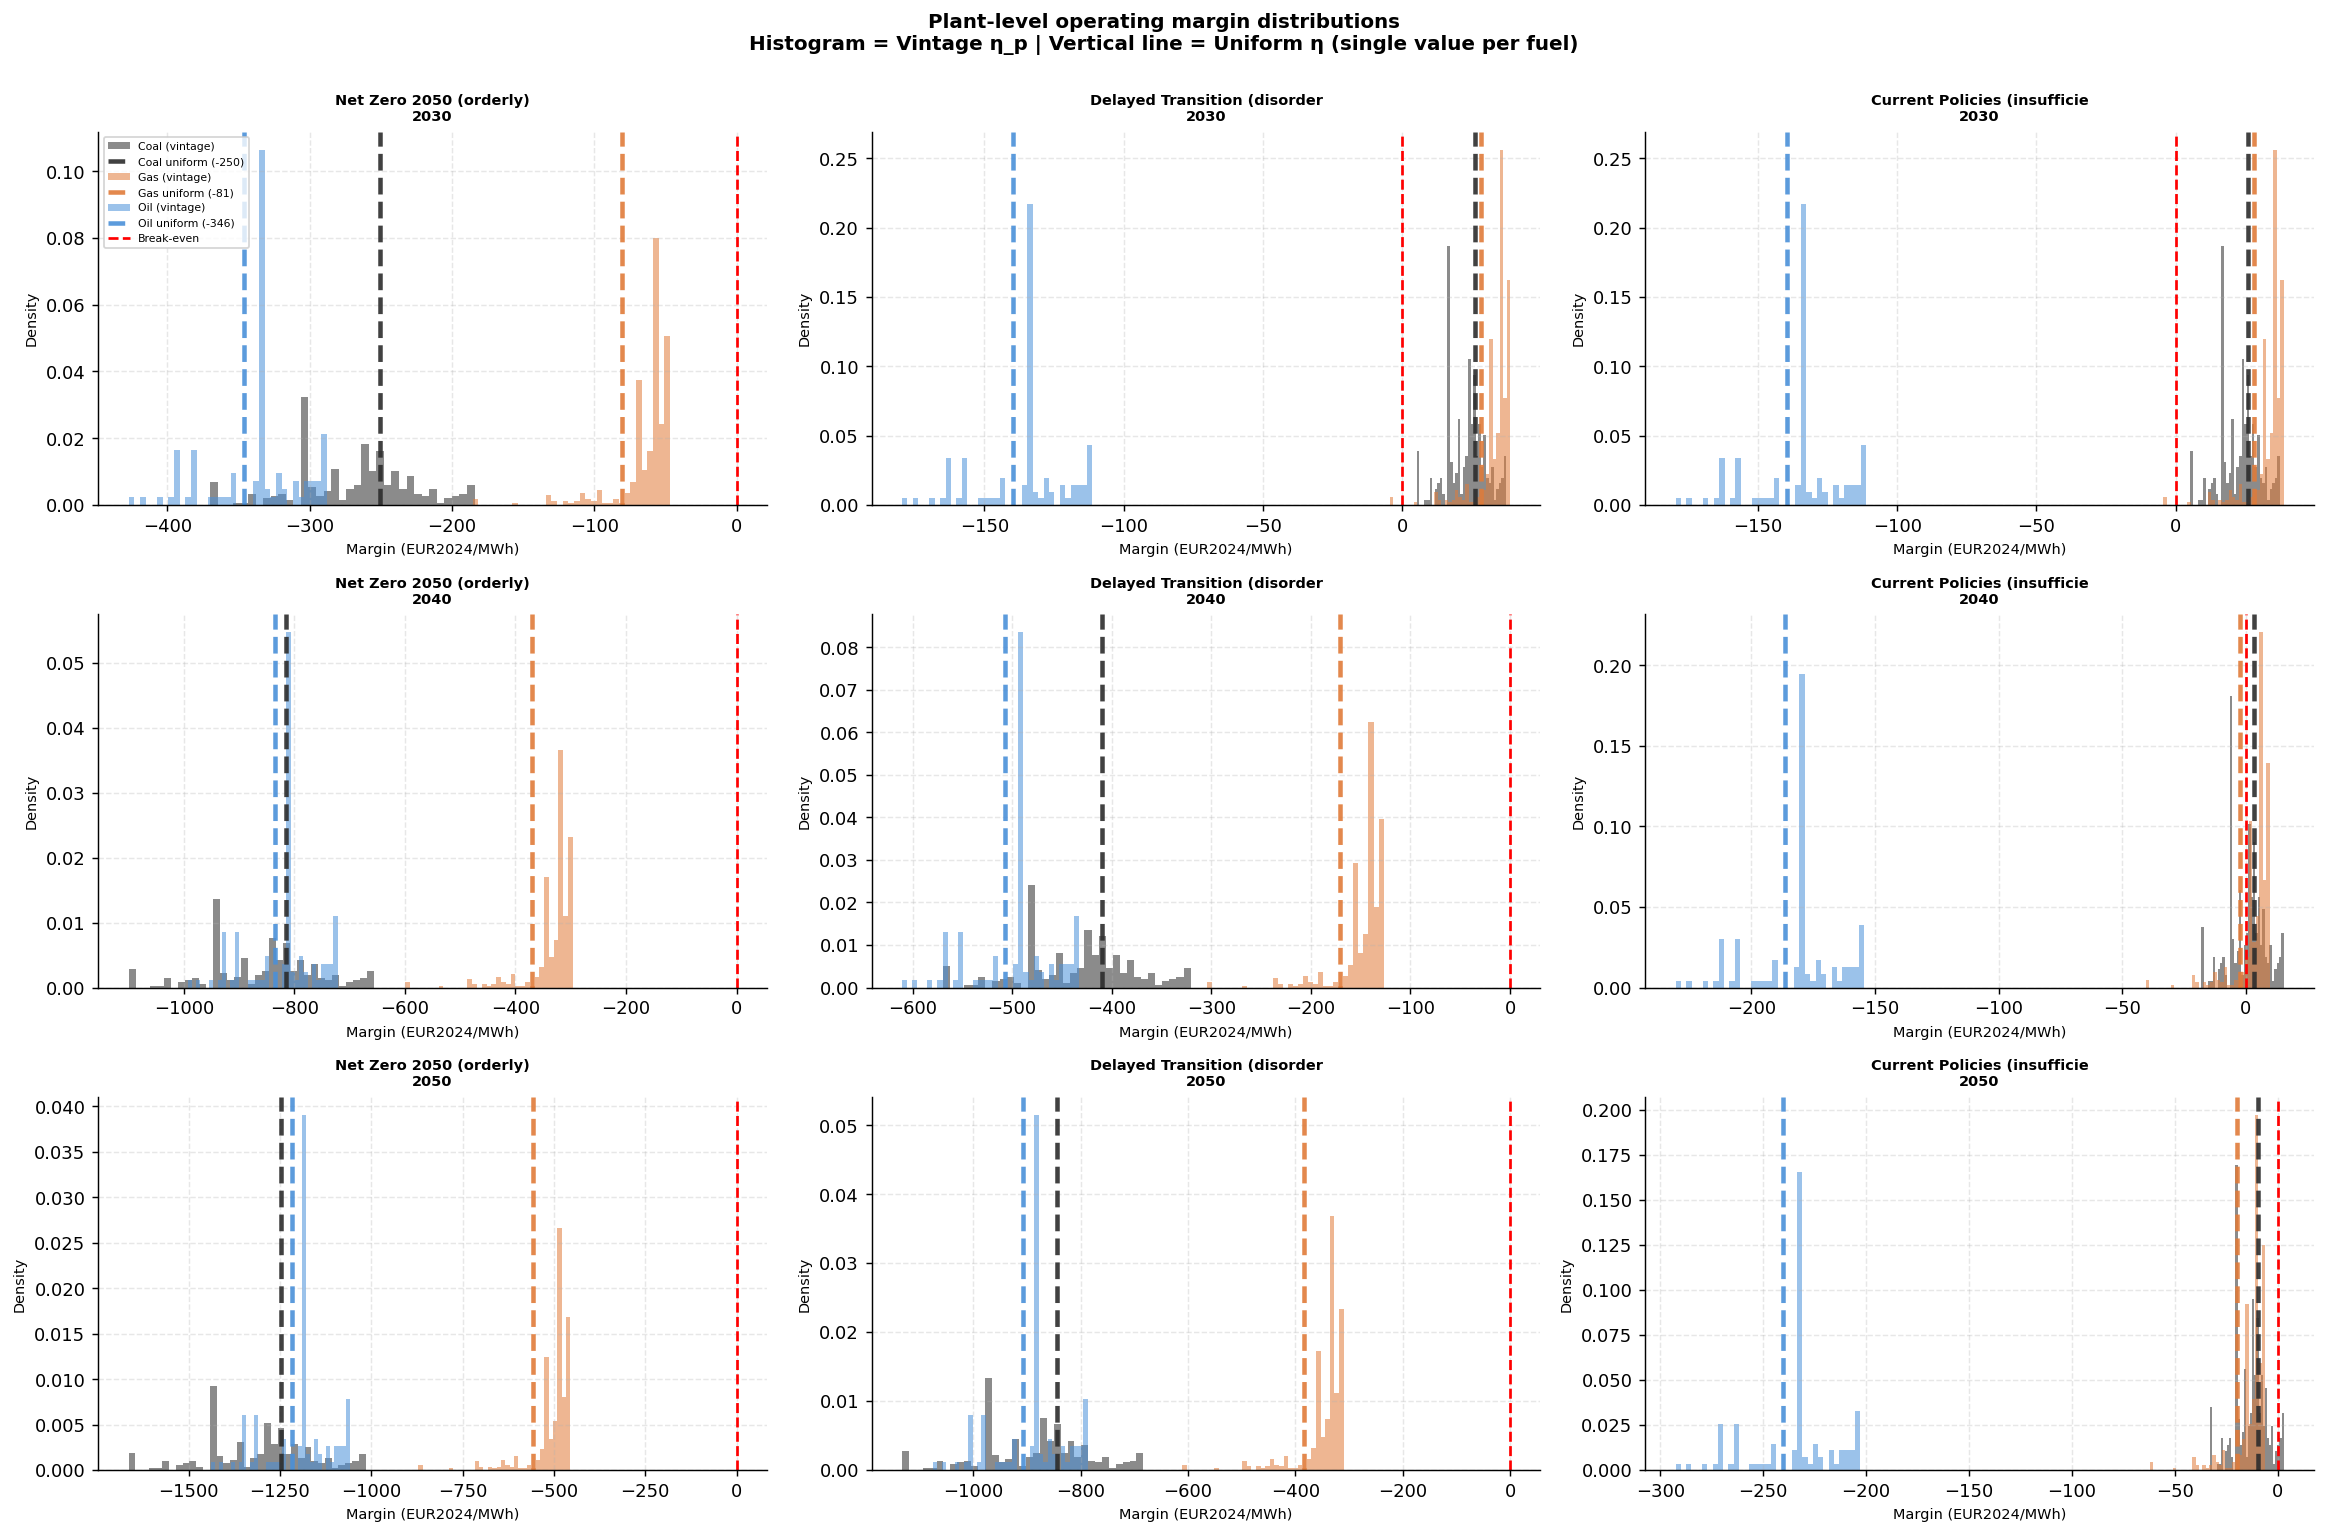

In [30]:
fig, axes = plt.subplots(len(HORIZONS), len(SCENARIOS),
                         figsize=(6*len(SCENARIOS), 4*len(HORIZONS)))
if len(HORIZONS) == 1:
    axes = axes[np.newaxis, :]

for row_i, yr in enumerate(HORIZONS):
    for col_j, scenario in enumerate(SCENARIOS):
        ax = axes[row_i, col_j]
        sub_u = df_u[(df_u['scenario'] == scenario) & (df_u['year'] == yr)]
        sub_v = df_v[(df_v['scenario'] == scenario) & (df_v['year'] == yr)]

        for fuel in ['coal','gas','oil']:
            # Vintage — vraie distribution → histogramme
            vals_v = sub_v[sub_v['fuel'] == fuel]['margin'].dropna()
            if len(vals_v):
                ax.hist(vals_v, bins=35, alpha=0.55, color=FUEL_COLORS[fuel],
                        label=f'{fuel.capitalize()} (vintage)', density=True)
            # Uniform — valeur unique → ligne verticale
            vals_u = sub_u[sub_u['fuel'] == fuel]['margin'].dropna()
            if len(vals_u):
                m_u = vals_u.iloc[0]  # toutes identiques
                ax.axvline(m_u, color=FUEL_COLORS[fuel], linestyle='--',
                           linewidth=2.5, alpha=0.9,
                           label=f'{fuel.capitalize()} uniform ({m_u:.0f})')

        ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Break-even')
        ax.set_title(f"{SCENARIO_LABELS[scenario][:28]}\n{yr}", fontsize=8, fontweight='bold')
        ax.set_xlabel('Margin (EUR2024/MWh)', fontsize=8)
        ax.set_ylabel('Density', fontsize=8)
        if row_i == 0 and col_j == 0:
            ax.legend(fontsize=6)

fig.suptitle('Plant-level operating margin distributions\n'
             'Histogram = Vintage η_p | Vertical line = Uniform η (single value per fuel)',
             fontsize=11, fontweight='bold')

plt.subplots_adjust(top=0.93)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('../../outputs/figures/fig_margin_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 EU-level stranded capacity — all definitions × both versions

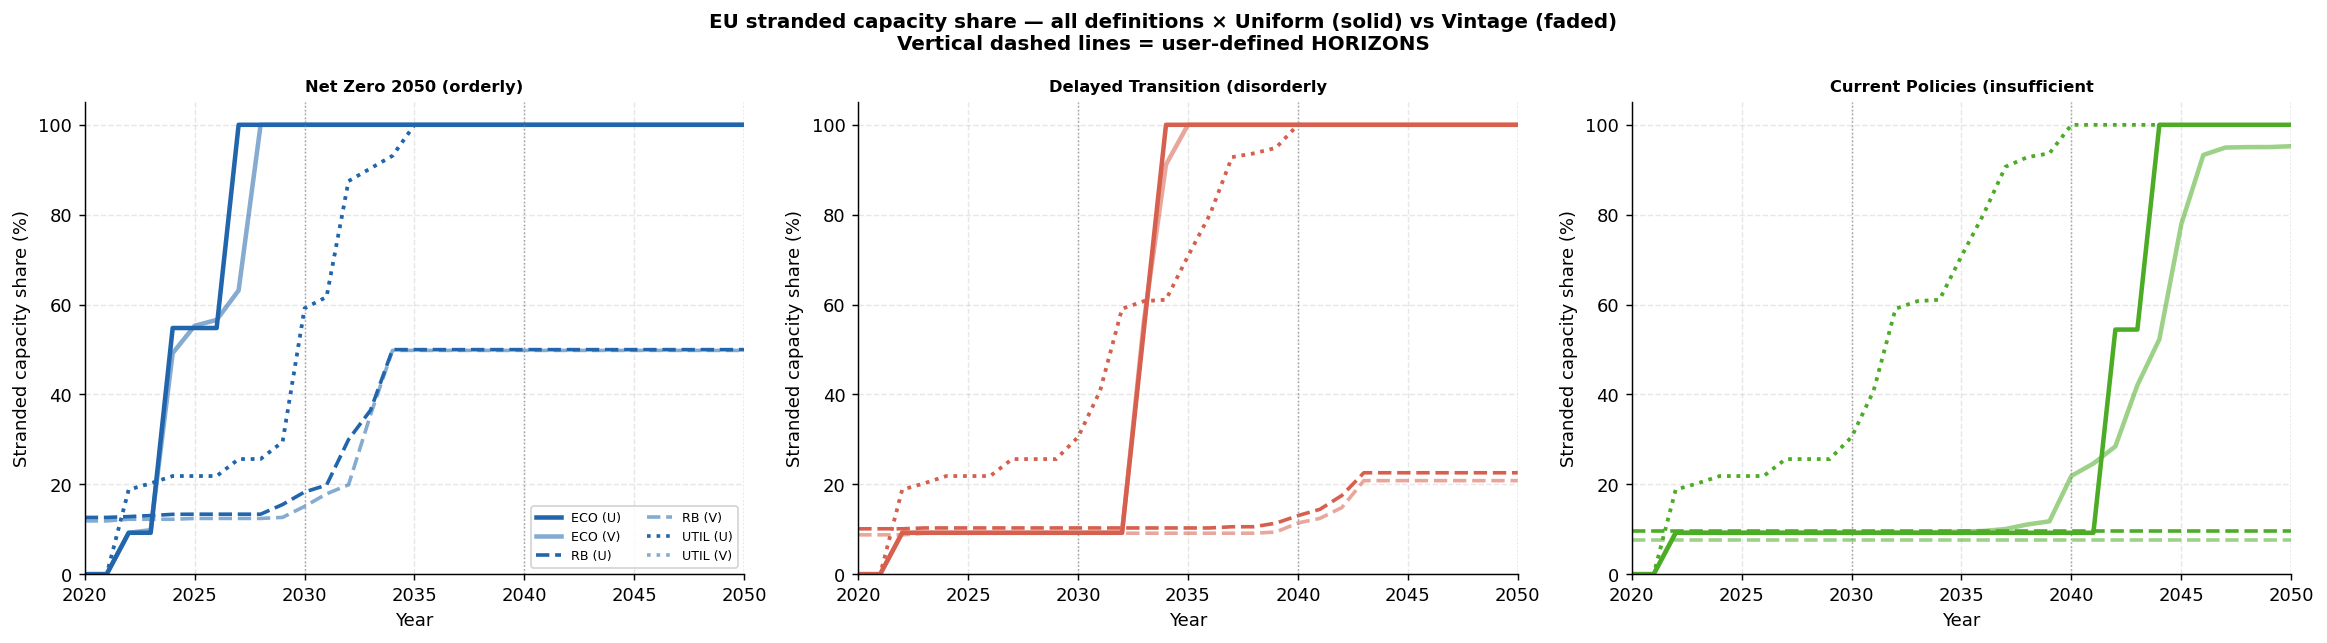

In [31]:
def eu_share_timeseries(df_s, defn):
    """EU capacity-weighted stranded share by (scenario, year)."""
    return (
        df_s.groupby(['scenario','year'])
        .apply(lambda x: np.average(x[defn], weights=x['capacity_mw']))
        .reset_index(name='share')
    )

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, scenario in zip(axes, SCENARIOS):
    for defn, ls, lw in [('stranded_eco','-',2.5), ('stranded_rb','--',2), ('stranded_util',':',2)]:
        for version, df_s, color in [('uniform', df_u, SCENARIO_COLORS[scenario]),
                                      ('vintage', df_v, SCENARIO_COLORS[scenario])]:
            alpha = 1.0 if version == 'uniform' else 0.55
            sub = eu_share_timeseries(df_s, defn)
            sub = sub[sub['scenario'] == scenario]
            ax.plot(sub['year'], sub['share']*100,
                    color=color, linestyle=ls, linewidth=lw, alpha=alpha,
                    label=f"{defn.replace('stranded_','').upper()} ({'U' if version=='uniform' else 'V'})")
    for yr in HORIZONS:
        ax.axvline(yr, color='grey', linestyle=':', linewidth=0.8, alpha=0.7)
    ax.set_title(SCENARIO_LABELS[scenario][:30], fontsize=9, fontweight='bold')
    ax.set_xlabel('Year'); ax.set_ylabel('Stranded capacity share (%)')
    ax.set_xlim(2020, 2050); ax.set_ylim(0, 105)

axes[0].legend(fontsize=7, ncol=2)
fig.suptitle('EU stranded capacity share — all definitions × Uniform (solid) vs Vintage (faded)\n'
             'Vertical dashed lines = user-defined HORIZONS',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../../outputs/figures/fig_eu_stranding_all_definitions.png', dpi=150, bbox_inches='tight')
plt.show()


## Task 5 — Country-level Stranding Indicators

### Aggregation formula (from subject)
$$\text{Stranded Share}_{c,s,t} = \frac{\sum_{p \in c} \mathbf{1}_{\text{stranded}_{p,t,s}} \cdot MW_p}{\sum_{p \in c} MW_p}$$

Computed for each country, scenario, year.  
Decomposed by: fuel (coal vs gas vs oil), vintage (pre/post 2000).  
Generation-at-risk = stranded capacity × CF × 8760 h (optional metric).


In [32]:
def aggregate_country(df_s, defn='stranded_eco'):
    """
    Full country-level aggregation:
    - Overall stranded share (country × scenario × year)
    - By fuel
    - By vintage
    - Generation-at-risk
    Returns dict of DataFrames.
    """
    grp_base = ['country','scenario','year']

    # Overall
    overall = (
        df_s.groupby(grp_base)
        .apply(lambda x: pd.Series({
            'stranded_cap_mw' : (x[defn] * x['capacity_mw']).sum(),
            'total_cap_mw'    : x['capacity_mw'].sum(),
            'gar_mwh'         : (x[defn] * x['capacity_mw'] * x['cf_t'] * 8760).sum(),
        }))
        .reset_index()
    )
    overall['stranded_share'] = (overall['stranded_cap_mw'] / overall['total_cap_mw']).fillna(0)
    overall['gar_gwh']        = overall['gar_mwh'] / 1e6

    # By fuel
    by_fuel = (
        df_s.groupby(grp_base + ['fuel'])
        .apply(lambda x: pd.Series({
            'stranded_cap_mw': (x[defn] * x['capacity_mw']).sum(),
            'total_cap_mw'   : x['capacity_mw'].sum(),
        }))
        .reset_index()
    )
    by_fuel['stranded_share'] = (by_fuel['stranded_cap_mw'] / by_fuel['total_cap_mw']).fillna(0)

    # By vintage
    by_vintage = (
        df_s.groupby(grp_base + ['vintage'])
        .apply(lambda x: pd.Series({
            'stranded_cap_mw': (x[defn] * x['capacity_mw']).sum(),
            'total_cap_mw'   : x['capacity_mw'].sum(),
        }))
        .reset_index()
    )
    by_vintage['stranded_share'] = (
        by_vintage['stranded_cap_mw'] / by_vintage['total_cap_mw']
    ).fillna(0)

    return {'overall': overall, 'by_fuel': by_fuel, 'by_vintage': by_vintage}

# Run for primary config + both versions
AGG = {}
for version, df_s in [('uniform', df_u), ('vintage', df_v)]:
    for defn in ['stranded_eco','stranded_rb','stranded_util']:
        AGG[(version, defn)] = aggregate_country(df_s, defn)

primary_overall = AGG[(PRIMARY_VERSION, PRIMARY_STRANDING)]['overall']
print(f"Aggregation done — primary: {PRIMARY_VERSION} × {PRIMARY_STRANDING}")
print(f"Countries in dataset: {primary_overall['country'].nunique()}")


Aggregation done — primary: uniform × stranded_eco
Countries in dataset: 26


### 5.1 Summary table — stranded share at user-defined horizons

In [33]:
# EU aggregate at HORIZONS for all scenario × version × definition
records = []
for version, df_s in [('uniform', df_u), ('vintage', df_v)]:
    for defn in ['stranded_eco','stranded_rb','stranded_util']:
        ts = eu_share_timeseries(df_s, defn)
        for scenario in SCENARIOS:
            sub = ts[ts['scenario'] == scenario]
            row = {'version': version, 'definition': defn, 'scenario': scenario}
            for yr in HORIZONS:
                v = sub[sub['year'] == yr]['share'].values
                row[str(yr)] = round(v[0]*100, 1) if len(v) else np.nan
            records.append(row)

df_summary = pd.DataFrame(records)
print(f"EU aggregate stranded capacity share (%) at HORIZONS={HORIZONS}\n")
display(df_summary.sort_values(['version','definition','scenario']))


EU aggregate stranded capacity share (%) at HORIZONS=[2030, 2040, 2050]



,version,definition,scenario,2030,2040,2050
2,uniform,stranded_eco,Current Policies,9.200,9.200,100.000
1,uniform,stranded_eco,Delayed transition,9.200,100.000,100.000
0,uniform,stranded_eco,Net Zero 2050,100.000,100.000,100.000
5,uniform,stranded_rb,Current Policies,9.600,9.600,9.600
4,uniform,stranded_rb,Delayed transition,10.300,13.000,22.600
3,uniform,stranded_rb,Net Zero 2050,18.300,50.000,50.000
8,uniform,stranded_util,Current Policies,30.500,100.000,100.000
7,uniform,stranded_util,Delayed transition,30.500,100.000,100.000
6,uniform,stranded_util,Net Zero 2050,59.200,100.000,100.000
11,vintage,stranded_eco,Current Policies,9.200,21.900,95.200


### 5.2 Heatmap — country × scenario at each user-defined horizon

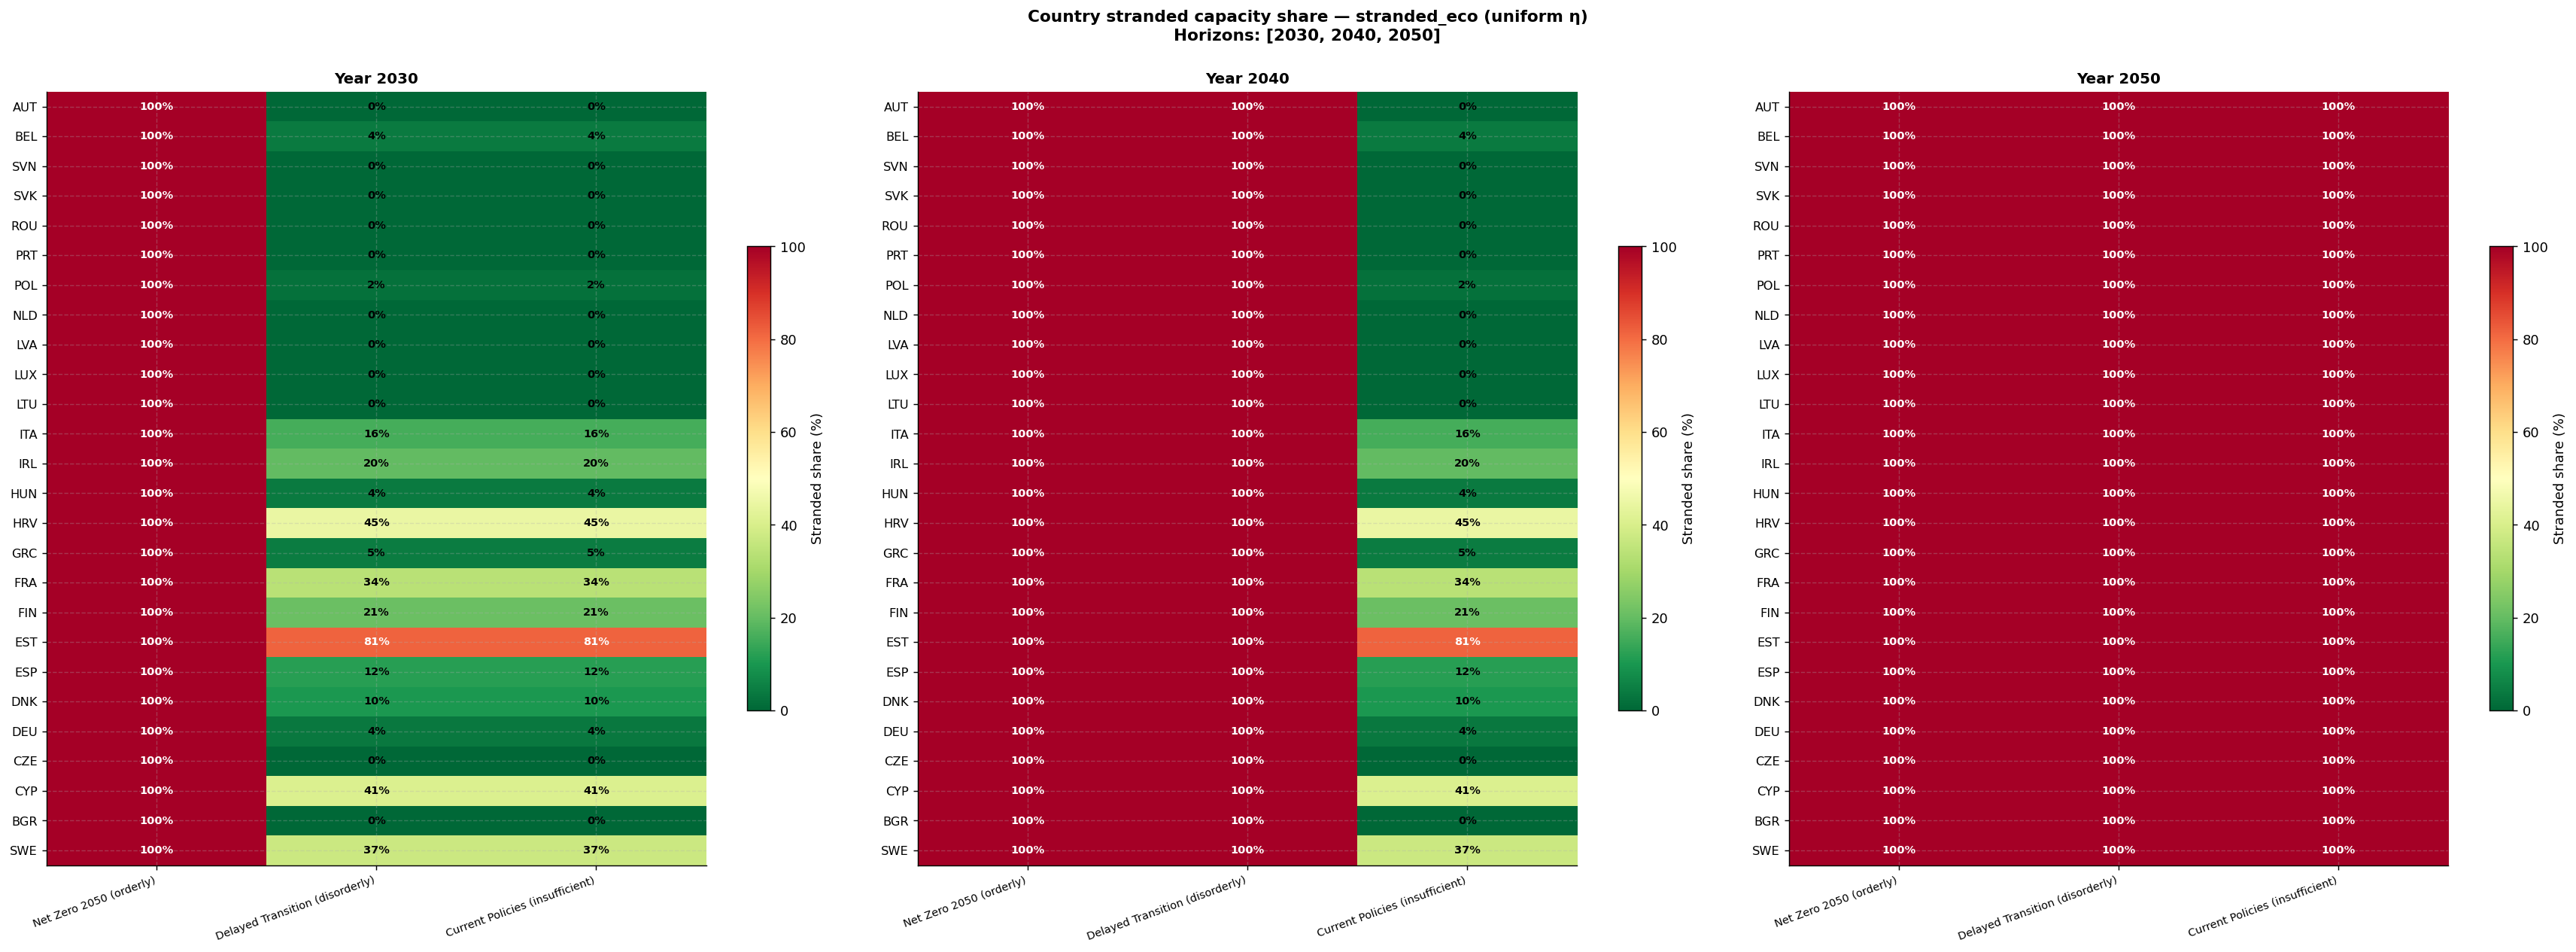

In [34]:
n_h   = len(HORIZONS)
ncols = min(3, n_h)
nrows = int(np.ceil(n_h / ncols))

fig, axes = plt.subplots(nrows, ncols,
    figsize=(9*ncols, max(8, primary_overall['country'].nunique()*0.38) * nrows))
axes_flat = np.array(axes).flatten()

for ax_idx, yr in enumerate(HORIZONS):
    ax = axes_flat[ax_idx]
    sub = primary_overall[primary_overall['year'] == yr]
    pivot = sub.pivot_table(
        index='country', columns='scenario', values='stranded_share'
    ).reindex(columns=SCENARIOS) * 100
    pivot = pivot.sort_values('Net Zero 2050', ascending=False).dropna(how='all')

    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=100)
    ax.set_xticks(range(len(SCENARIOS)))
    ax.set_xticklabels([SCENARIO_LABELS[s] for s in SCENARIOS],
                       fontsize=8, rotation=20, ha='right')
    ax.set_yticks(range(len(pivot)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    for i in range(len(pivot)):
        for j in range(len(SCENARIOS)):
            val = pivot.iloc[i, j]
            if not np.isnan(val):
                txt_col = 'white' if val > 60 else 'black'
                ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                        fontsize=8, color=txt_col, fontweight='bold')
    ax.set_title(f'Year {yr}', fontweight='bold', fontsize=11)
    plt.colorbar(im, ax=ax, label='Stranded share (%)', shrink=0.6)

for ax_idx in range(n_h, len(axes_flat)):
    axes_flat[ax_idx].set_visible(False)

fig.suptitle(f'Country stranded capacity share — {PRIMARY_STRANDING} ({PRIMARY_VERSION} η)\n'
             f'Horizons: {HORIZONS}',
             fontsize=12, fontweight='bold')

plt.subplots_adjust(top=0.93)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('../../outputs/figures/fig_heatmap_country_scenario.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Country ranking — top N countries over time (dynamic horizons)

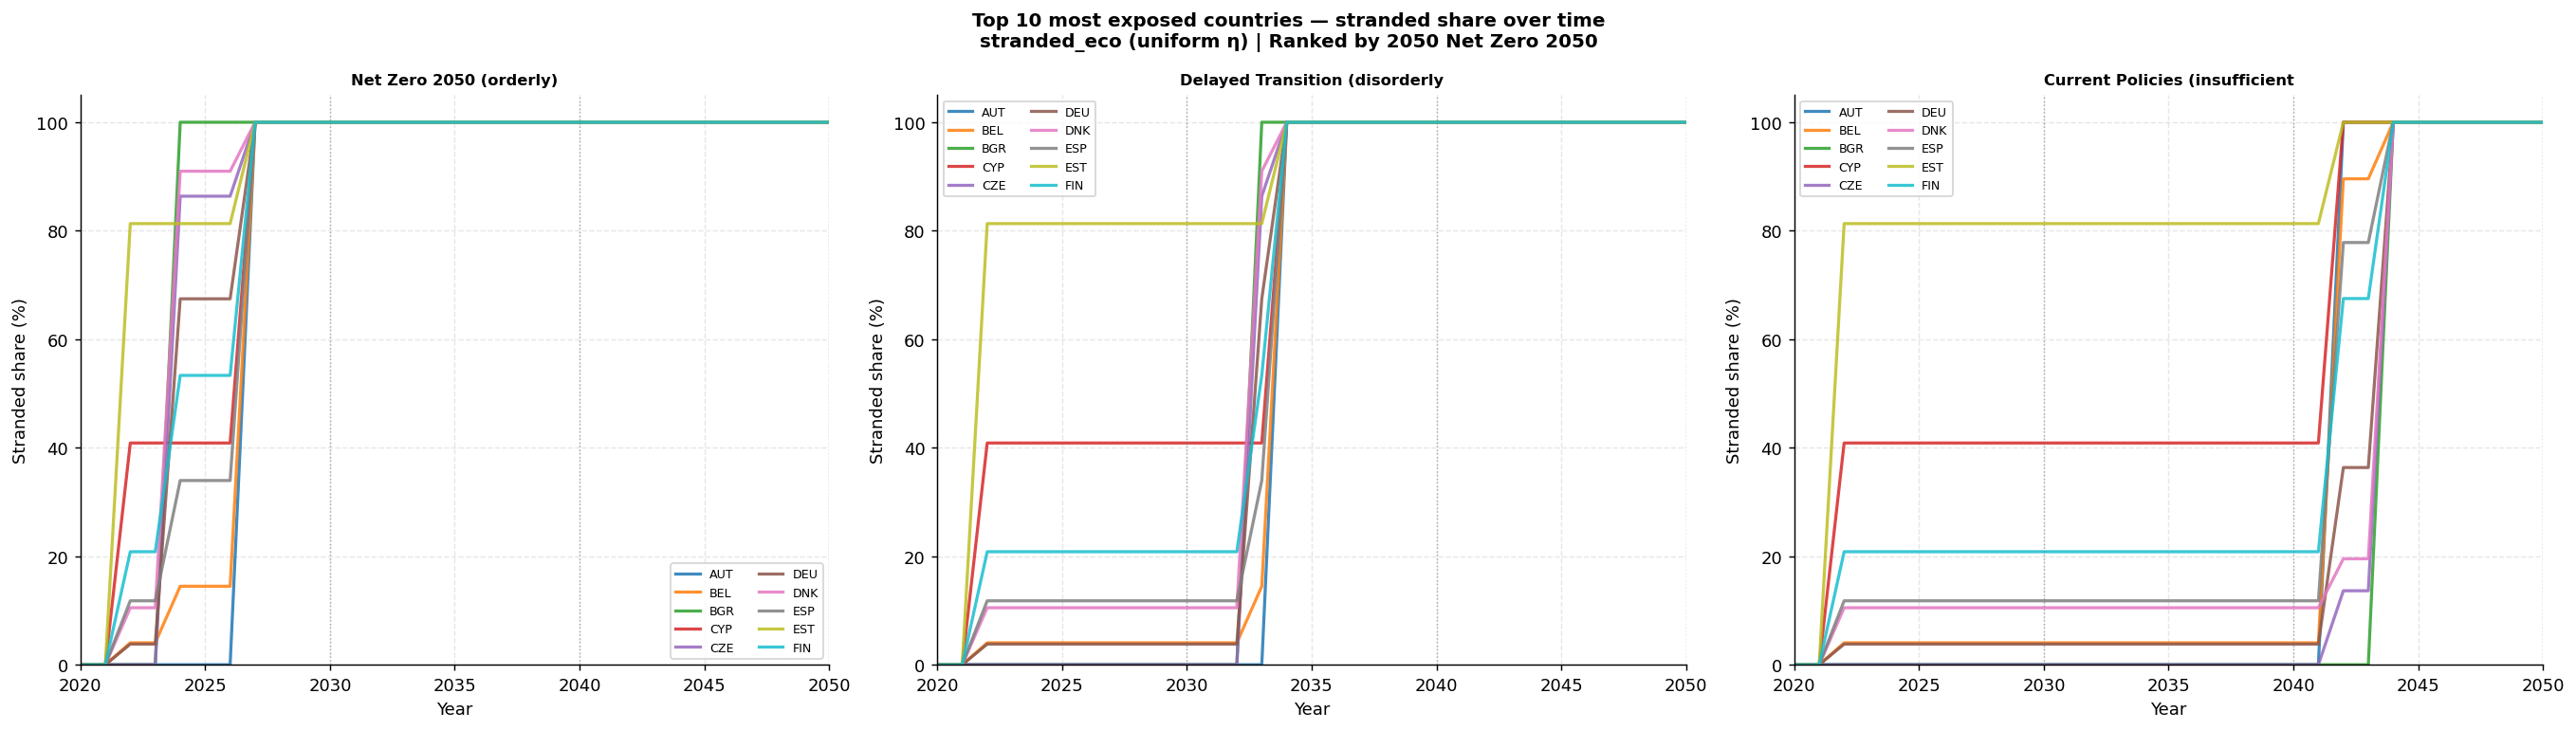

In [35]:
# Rank countries by stranded share at LAST horizon under Net Zero 2050
last_yr = max(HORIZONS)
ranking_base = (
    primary_overall[
        (primary_overall['scenario'] == 'Net Zero 2050') &
        (primary_overall['year'] == last_yr)
    ]
    .nlargest(TOP_N_COUNTRIES, 'stranded_share')['country'].tolist()
)

fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(7*len(SCENARIOS), 6), sharey=False)

for ax, scenario in zip(axes, SCENARIOS):
    sub = primary_overall[
        (primary_overall['scenario'] == scenario) &
        (primary_overall['country'].isin(ranking_base))
    ]
    for country in ranking_base:
        ts = sub[sub['country'] == country].sort_values('year')
        ax.plot(ts['year'], ts['stranded_share']*100,
                linewidth=1.8, label=country, alpha=0.85)
    for yr in HORIZONS:
        ax.axvline(yr, color='grey', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.set_title(SCENARIO_LABELS[scenario][:30], fontsize=9, fontweight='bold')
    ax.set_xlabel('Year'); ax.set_ylabel('Stranded share (%)')
    ax.set_xlim(2020, 2050); ax.set_ylim(0, 105)
    ax.legend(fontsize=7, ncol=2)

fig.suptitle(f'Top {TOP_N_COUNTRIES} most exposed countries — stranded share over time\n'
             f'{PRIMARY_STRANDING} ({PRIMARY_VERSION} η) | Ranked by {last_yr} Net Zero 2050',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../../outputs/figures/fig_country_ranking_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.4 Stranding by fuel type — EU aggregate

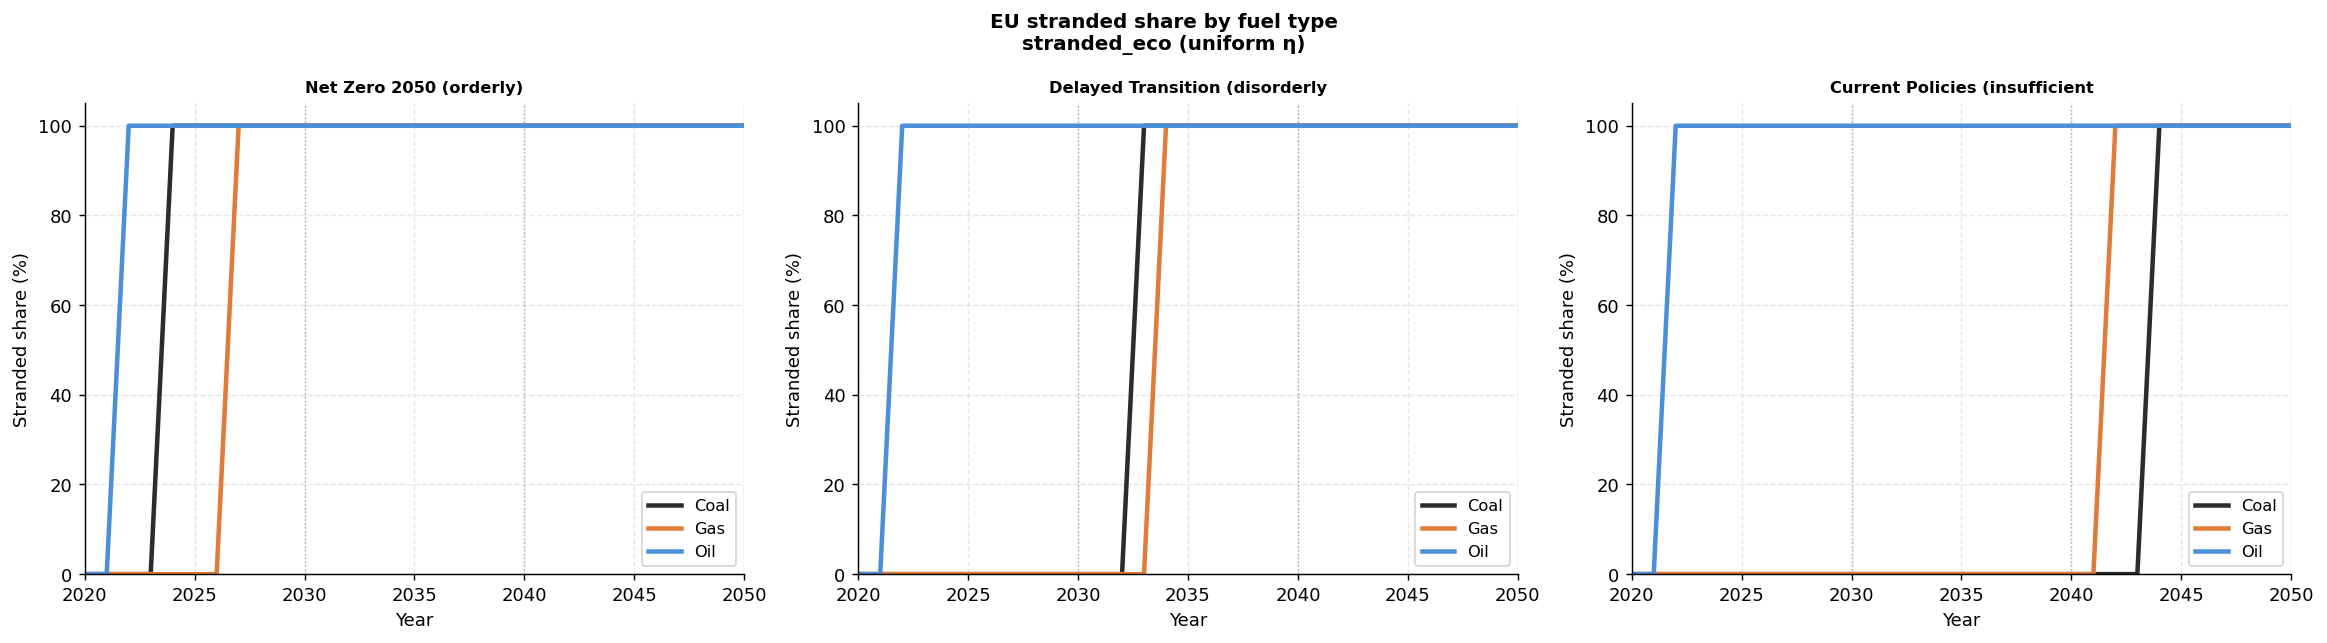

In [36]:
by_fuel_u = AGG[(PRIMARY_VERSION, PRIMARY_STRANDING)]['by_fuel']

fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(6*len(SCENARIOS), 5))

for ax, scenario in zip(axes, SCENARIOS):
    sub = by_fuel_u[by_fuel_u['scenario'] == scenario]
    for fuel in ['coal','gas','oil']:
        ts = sub[sub['fuel'] == fuel].groupby('year').apply(
            lambda x: np.average(x['stranded_share'], weights=x['total_cap_mw'])
        ).reset_index(name='share')
        ax.plot(ts['year'], ts['share']*100, color=FUEL_COLORS[fuel],
                linewidth=2.5, label=fuel.capitalize())
    for yr in HORIZONS:
        ax.axvline(yr, color='grey', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.set_title(SCENARIO_LABELS[scenario][:30], fontsize=9, fontweight='bold')
    ax.set_xlabel('Year'); ax.set_ylabel('Stranded share (%)')
    ax.set_xlim(2020, 2050); ax.set_ylim(0, 105)
    ax.legend(fontsize=9)

fig.suptitle(f'EU stranded share by fuel type\n{PRIMARY_STRANDING} ({PRIMARY_VERSION} η)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../../outputs/figures/fig_stranding_by_fuel.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.5 Stranding by vintage (pre/post 2000) — EU aggregate

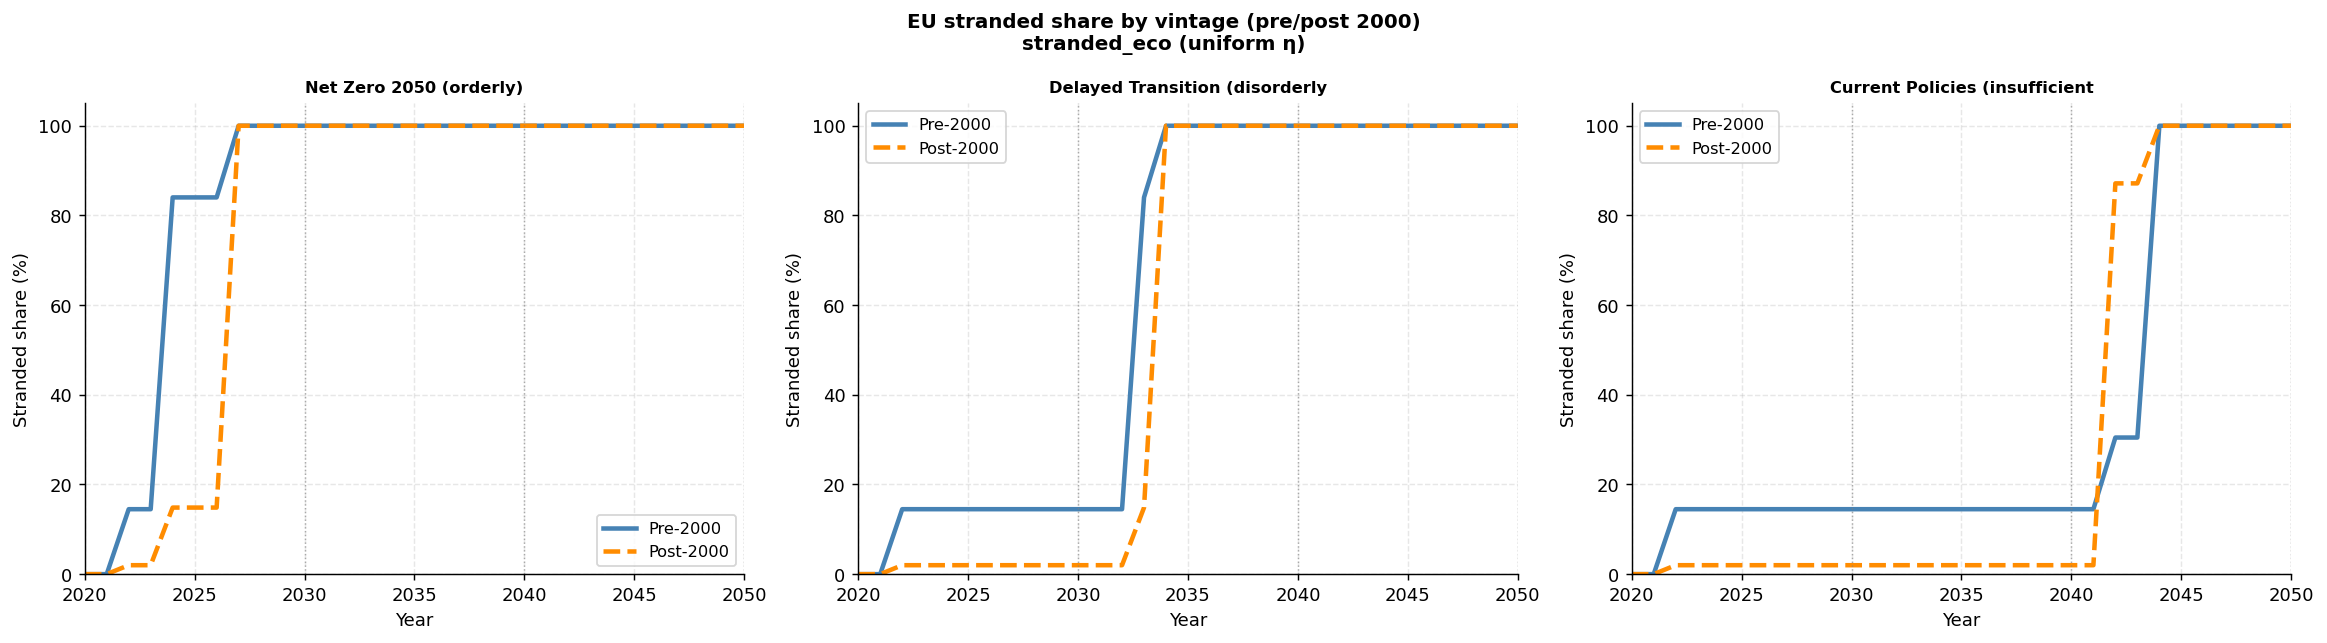

In [37]:
by_vint_u = AGG[(PRIMARY_VERSION, PRIMARY_STRANDING)]['by_vintage']

fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(6*len(SCENARIOS), 5))
VINTAGE_STYLES = {'pre2000': ('-', 'steelblue', 'Pre-2000'),
                  'post2000': ('--', 'darkorange', 'Post-2000')}

for ax, scenario in zip(axes, SCENARIOS):
    sub = by_vint_u[by_vint_u['scenario'] == scenario]
    for vintage, (ls, color, label) in VINTAGE_STYLES.items():
        ts = sub[sub['vintage'] == vintage].groupby('year').apply(
            lambda x: np.average(x['stranded_share'], weights=x['total_cap_mw'])
        ).reset_index(name='share')
        ax.plot(ts['year'], ts['share']*100, color=color, linestyle=ls,
                linewidth=2.5, label=label)
    for yr in HORIZONS:
        ax.axvline(yr, color='grey', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.set_title(SCENARIO_LABELS[scenario][:30], fontsize=9, fontweight='bold')
    ax.set_xlabel('Year'); ax.set_ylabel('Stranded share (%)')
    ax.set_xlim(2020, 2050); ax.set_ylim(0, 105)
    ax.legend(fontsize=9)

fig.suptitle(f'EU stranded share by vintage (pre/post 2000)\n{PRIMARY_STRANDING} ({PRIMARY_VERSION} η)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../../outputs/figures/fig_stranding_by_vintage.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.6 Generation-at-risk (optional) — EU aggregate

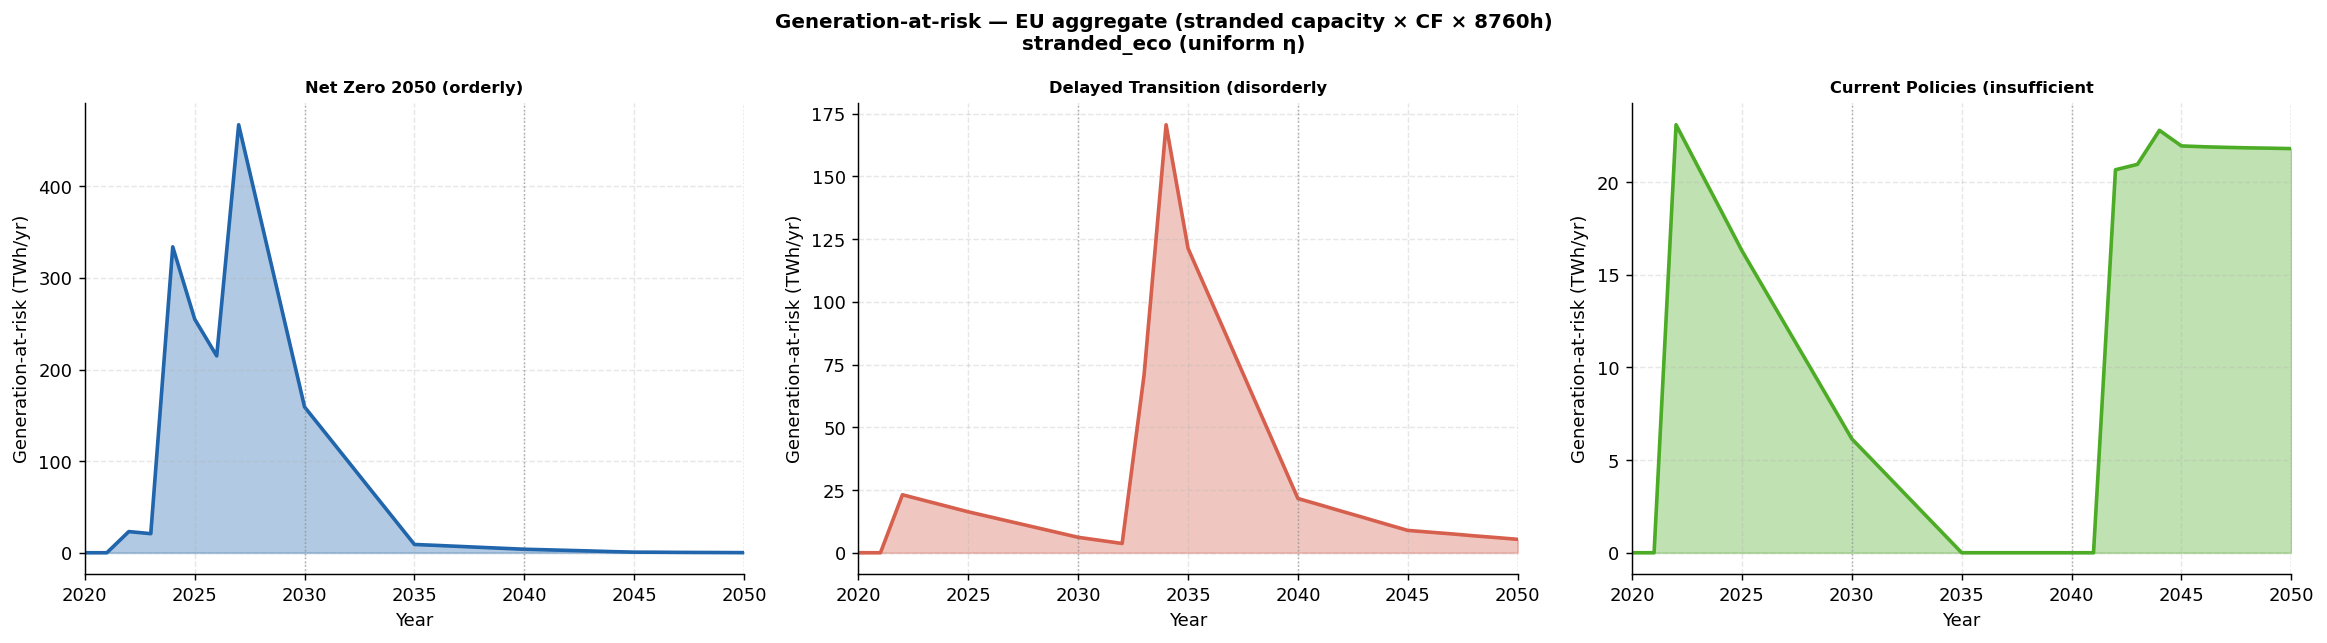


Generation-at-risk (TWh/yr) at HORIZONS=[2030, 2040, 2050]:


year,2030,2040,2050
scenario,,,
Current Policies,6.100,0.000,21.800
Delayed transition,6.100,21.600,5.300
Net Zero 2050,159.200,3.800,0.100


In [38]:
fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(6*len(SCENARIOS), 5))

for ax, scenario in zip(axes, SCENARIOS):
    sub = primary_overall[primary_overall['scenario'] == scenario].groupby('year')['gar_gwh'].sum().reset_index()
    ax.fill_between(sub['year'], sub['gar_gwh'], alpha=0.35,
                    color=SCENARIO_COLORS[scenario])
    ax.plot(sub['year'], sub['gar_gwh'], color=SCENARIO_COLORS[scenario], linewidth=2)
    for yr in HORIZONS:
        ax.axvline(yr, color='grey', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.set_title(SCENARIO_LABELS[scenario][:30], fontsize=9, fontweight='bold')
    ax.set_xlabel('Year'); ax.set_ylabel('Generation-at-risk (TWh/yr)')
    ax.set_xlim(2020, 2050); ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))

fig.suptitle(f'Generation-at-risk — EU aggregate (stranded capacity × CF × 8760h)\n'
             f'{PRIMARY_STRANDING} ({PRIMARY_VERSION} η)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../../outputs/figures/fig_generation_at_risk.png', dpi=150, bbox_inches='tight')
plt.show()

# Table at HORIZONS
print(f"\nGeneration-at-risk (TWh/yr) at HORIZONS={HORIZONS}:")
gar_table = primary_overall[primary_overall['year'].isin(HORIZONS)].groupby(
    ['scenario','year'])['gar_gwh'].sum().unstack('year').round(1)
display(gar_table)


### 5.7 Country ranking bar chart — snapshot at each horizon

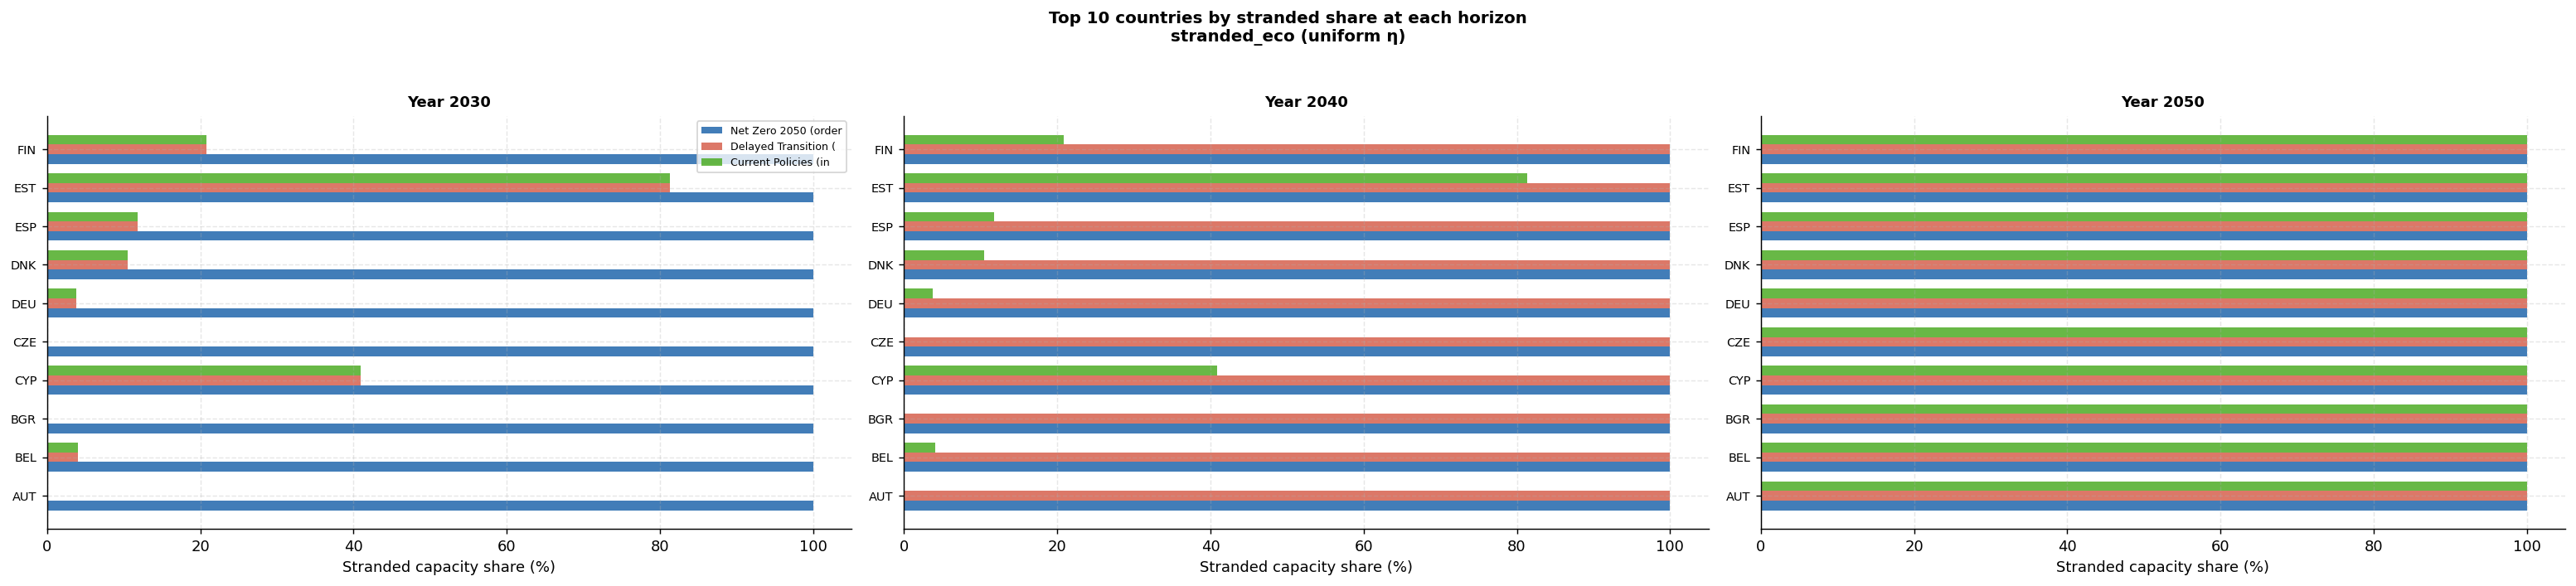

In [39]:
n_h   = len(HORIZONS)
ncols = min(3, n_h)
nrows = int(np.ceil(n_h / ncols))

fig, axes = plt.subplots(nrows, ncols,
    figsize=(8*ncols, (TOP_N_COUNTRIES*0.45 + 1) * nrows))
axes_flat = np.array(axes).flatten()

for ax_idx, yr in enumerate(HORIZONS):
    ax = axes_flat[ax_idx]
    sub = primary_overall[primary_overall['year'] == yr]

    countries_top = (sub[sub['scenario'] == 'Net Zero 2050']
                     .nlargest(TOP_N_COUNTRIES, 'stranded_share')['country'].tolist())

    top_sub = sub[sub['country'].isin(countries_top)].copy()
    pivot = (top_sub.pivot_table(index='country', columns='scenario', values='stranded_share')
             .reindex(countries_top).reindex(columns=SCENARIOS) * 100)
    pivot = pivot.sort_values('Net Zero 2050', ascending=True)

    x     = np.arange(len(pivot))
    width = 0.25
    for s_idx, (scenario, color) in enumerate(SCENARIO_COLORS.items()):
        vals = pivot[scenario].fillna(0).values
        ax.barh(x + s_idx*width, vals, width, color=color, alpha=0.85,
                label=SCENARIO_LABELS[scenario][:20])
    ax.set_yticks(x + width)
    ax.set_yticklabels(pivot.index, fontsize=8)
    ax.set_xlabel('Stranded capacity share (%)')
    ax.set_title(f'Year {yr}', fontweight='bold', fontsize=10)
    if ax_idx == 0:
        ax.legend(fontsize=7)

for ax_idx in range(n_h, len(axes_flat)):
    axes_flat[ax_idx].set_visible(False)

fig.suptitle(f'Top {TOP_N_COUNTRIES} countries by stranded share at each horizon\n'
             f'{PRIMARY_STRANDING} ({PRIMARY_VERSION} η)',
             fontsize=11, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('../../outputs/figures/fig_country_ranking_snapshot.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 6 — Portfolio Transition Risk

Two stylised financial portfolios, as per the subject:

**Portfolio 1 — Utilities equity/bonds**  
Weights = national thermal capacity share in EU total (w_c = MW_c / MW_EU).  
Represents an equity investor whose exposure to each country is proportional  
to its share of EU thermal installed capacity.

**Portfolio 2 — Bank credit proxy (country × fuel sector)**  
Weights = capacity share by country AND fuel type (w_{c,f} = MW_{c,f} / MW_EU).  
Represents a bank loan portfolio diversified across EU utilities by country  
and fuel sector (coal, gas, oil). TRS is the weighted sum of fuel-level  
stranded shares within each country.

For each portfolio: TRS at HORIZONS, expected (mean over scenarios), worst-case (max over scenarios).

In [40]:
# ── Portfolio 1: capacity-weighted by country ──────────────────────
total_cap_eu  = metrics_u.groupby('country')['capacity_mw'].sum()
total_cap_all = total_cap_eu.sum()
cap_weights   = (total_cap_eu / total_cap_all).to_dict()

# ── Portfolio 2: capacity-weighted by country × fuel sector ────────
# w_{c,f} = MW_{c,f} / MW_EU_total
# Source: subject requirement "by country and utility sector"
cap_by_fuel   = metrics_u.groupby(['country','fuel'])['capacity_mw'].sum()
sector_weights = (cap_by_fuel / total_cap_all).to_dict()  # keys: (country, fuel)

print("Portfolio 1 — Capacity weights by country (top 5):")
for c, w in sorted(cap_weights.items(), key=lambda x: -x[1])[:5]:
    print(f"  {c}: {w*100:.1f}%")

print("\nPortfolio 2 — Capacity weights by country × fuel (top 10):")
for (c, f), w in sorted(sector_weights.items(), key=lambda x: -x[1])[:10]:
    print(f"  {c} / {f}: {w*100:.1f}%")

Portfolio 1 — Capacity weights by country (top 5):
  DEU: 23.9%
  ITA: 17.9%
  ESP: 12.6%
  POL: 10.6%
  NLD: 4.6%

Portfolio 2 — Capacity weights by country × fuel (top 10):
  DEU / coal: 15.2%
  ITA / gas: 12.3%
  POL / coal: 9.8%
  ESP / gas: 8.3%
  DEU / gas: 7.8%
  NLD / gas: 3.0%
  ITA / coal: 2.9%
  ITA / oil: 2.8%
  ESP / coal: 2.8%
  CZE / coal: 2.7%


In [41]:
def compute_trs(overall_df, weights):
    """
    Portfolio 1: TRS_{s,t} = Σ_c w_c × stranded_share_{c,s,t}
    weights = {country: w_c}
    """
    trs = []
    for (scenario, year), grp in overall_df.groupby(['scenario','year']):
        score = sum(weights.get(row['country'], 0) * row['stranded_share']
                    for _, row in grp.iterrows())
        trs.append({'scenario': scenario, 'year': year, 'trs': score})
    return pd.DataFrame(trs)

def compute_trs_sector(by_fuel_df, weights):
    """
    Portfolio 2: TRS_{s,t} = Σ_{c,f} w_{c,f} × stranded_share_{c,f,s,t}
    weights = {(country, fuel): w_{c,f}}
    """
    trs = []
    for (scenario, year), grp in by_fuel_df.groupby(['scenario','year']):
        score = sum(
            weights.get((row['country'], row['fuel']), 0) * row['stranded_share']
            for _, row in grp.iterrows()
        )
        trs.append({'scenario': scenario, 'year': year, 'trs': score})
    return pd.DataFrame(trs)

# Compute TRS for all combinations
trs_results = {}
for version, df_s in [('uniform', df_u), ('vintage', df_v)]:
    for defn in ['stranded_eco', 'stranded_rb', 'stranded_util']:
        overall  = AGG[(version, defn)]['overall']
        by_fuel  = AGG[(version, defn)]['by_fuel']
        trs_results[(version, defn, 'capacity')] = compute_trs(overall, cap_weights)
        trs_results[(version, defn, 'sector')]   = compute_trs_sector(by_fuel, sector_weights)

# Summary table at HORIZONS
print(f"\nTRS (%) at HORIZONS={HORIZONS} — {PRIMARY_STRANDING} ({PRIMARY_VERSION} η)\n")
for portfolio, pname in [('capacity','Portfolio 1 (Capacity)'),
                          ('sector',  'Portfolio 2 (Country × Fuel sector)')]:
    print(f"  {pname}")
    trs = trs_results[(PRIMARY_VERSION, PRIMARY_STRANDING, portfolio)]
    print(f"  {'Scenario':35s} " + " ".join(f"{yr:>8d}" for yr in HORIZONS))
    for scenario in SCENARIOS:
        sub = trs[trs['scenario'] == scenario]
        vals = " ".join(
            f"{sub[sub['year']==yr]['trs'].values[0]*100:8.1f}"
            if yr in sub['year'].values else "     N/A"
            for yr in HORIZONS
        )
        print(f"  {scenario:35s} {vals}")
    print()


TRS (%) at HORIZONS=[2030, 2040, 2050] — stranded_eco (uniform η)

  Portfolio 1 (Capacity)
  Scenario                                2030     2040     2050
  Net Zero 2050                          100.0    100.0    100.0
  Delayed transition                       9.2    100.0    100.0
  Current Policies                         9.2      9.2    100.0

  Portfolio 2 (Country × Fuel sector)
  Scenario                                2030     2040     2050
  Net Zero 2050                          100.0    100.0    100.0
  Delayed transition                       9.2    100.0    100.0
  Current Policies                         9.2      9.2    100.0



### 6.1 TRS evolution — both portfolios side by side

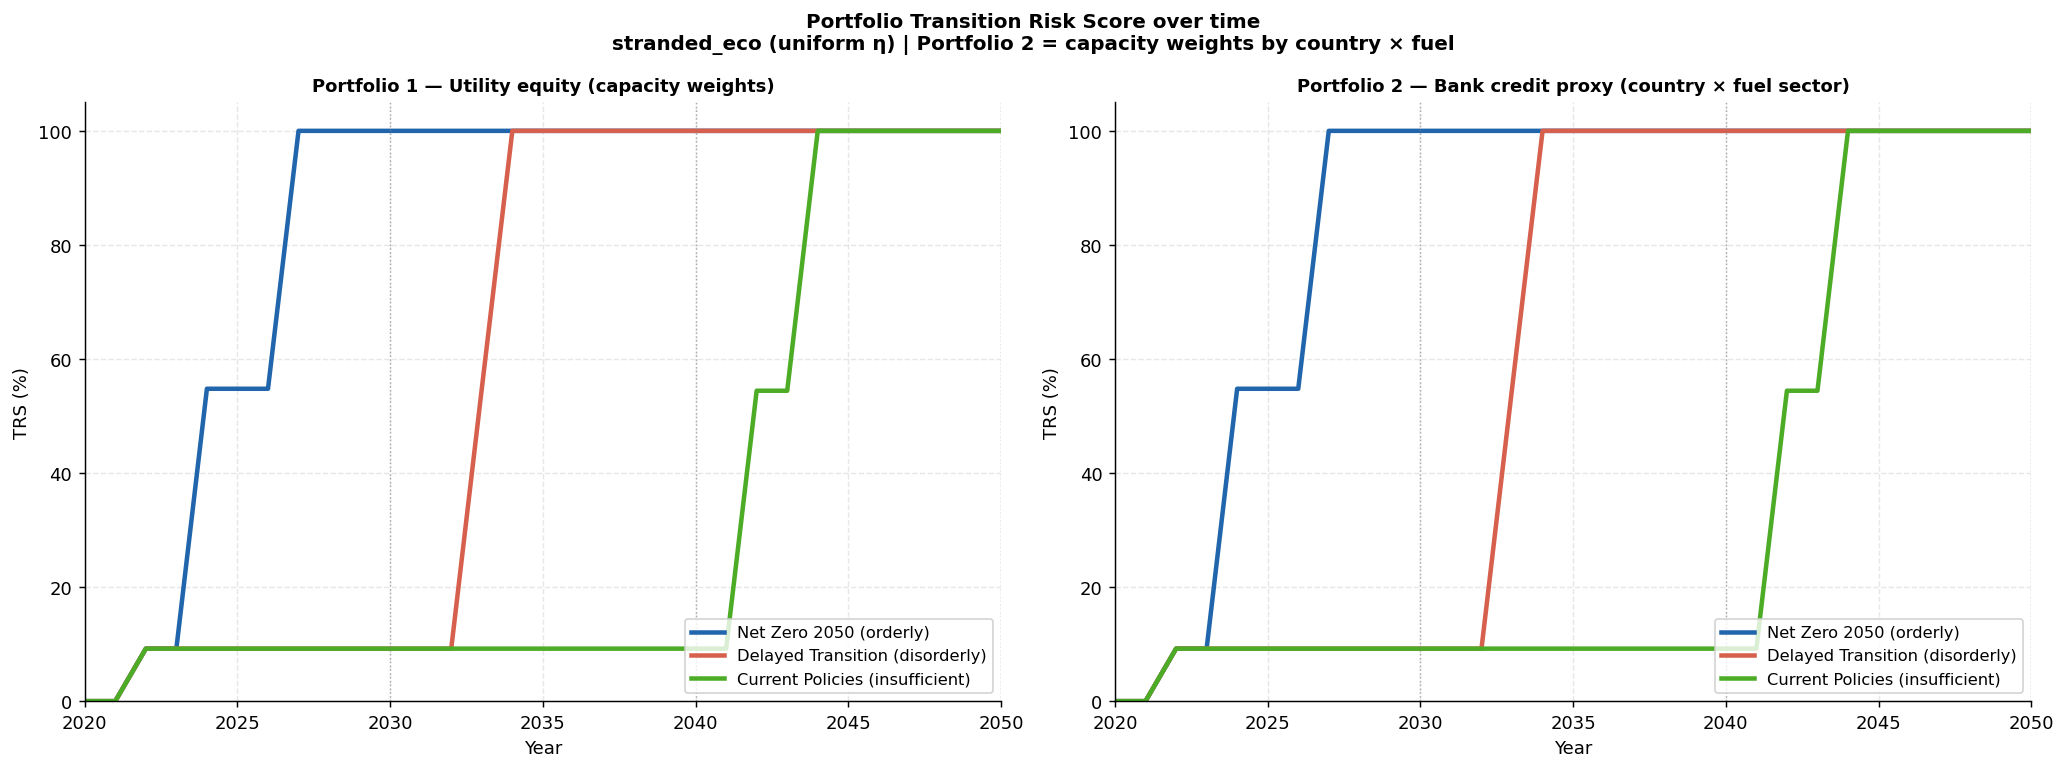

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

port_configs = [
    ('capacity', 'Portfolio 1 — Utility equity (capacity weights)'),
    ('sector',   'Portfolio 2 — Bank credit proxy (country × fuel sector)'),
]

for ax, (portfolio, title) in zip(axes, port_configs):
    trs = trs_results[(PRIMARY_VERSION, PRIMARY_STRANDING, portfolio)]
    for scenario in SCENARIOS:
        sub = trs[trs['scenario'] == scenario].sort_values('year')
        ax.plot(sub['year'], sub['trs']*100,
                color=SCENARIO_COLORS[scenario], linewidth=2.5,
                label=SCENARIO_LABELS[scenario])
    for yr in HORIZONS:
        ax.axvline(yr, color='grey', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.set_xlabel('Year'); ax.set_ylabel('TRS (%)')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlim(2020, 2050); ax.set_ylim(0)
    ax.legend(fontsize=9)


fig.suptitle(f'Portfolio Transition Risk Score over time\n'
             f'{PRIMARY_STRANDING} ({PRIMARY_VERSION} η) | Portfolio 2 = capacity weights by country × fuel',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../../outputs/figures/fig_trs_evolution.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.2 Expected stranded share and worst-case over scenarios

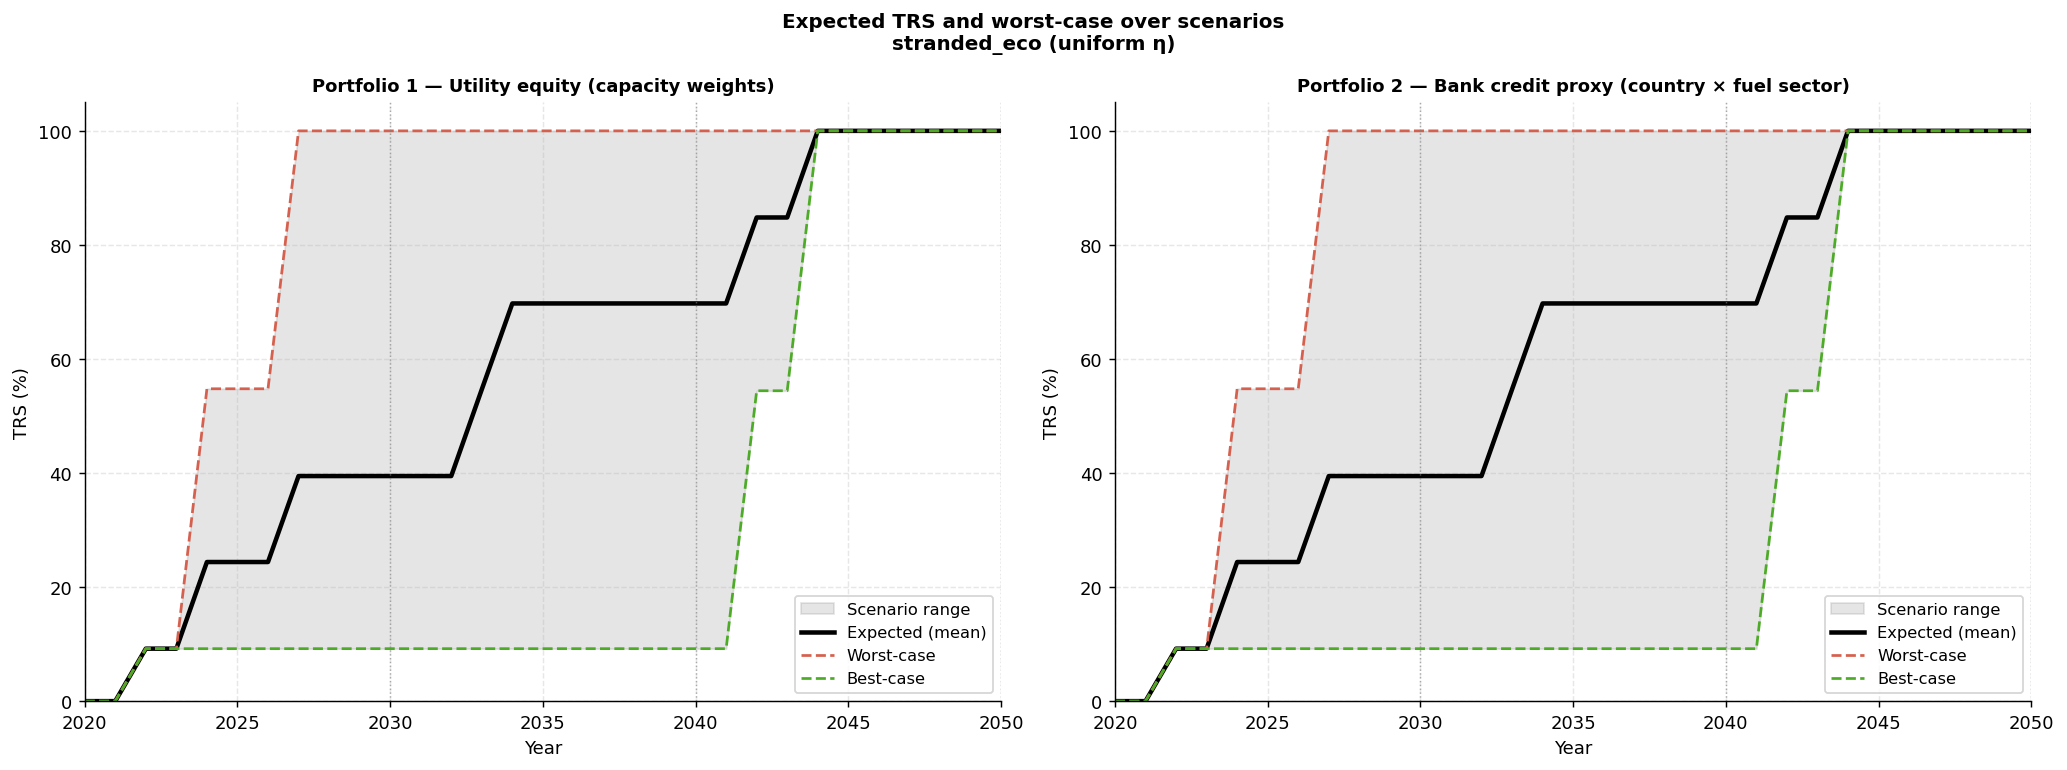


Worst-case TRS (%) across scenarios at HORIZONS=[2030, 2040, 2050]:
  Portfolio 1: {2030: 100.0, 2040: 100.0, 2050: 100.0}
  Portfolio 2: {2030: 100.0, 2040: 100.0, 2050: 100.0}


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (portfolio, title) in zip(axes, port_configs):
    trs = trs_results[(PRIMARY_VERSION, PRIMARY_STRANDING, portfolio)]
    trs_wide = trs.pivot_table(index='year', columns='scenario', values='trs')

    expected  = trs_wide.mean(axis=1) * 100
    worst     = trs_wide.max(axis=1) * 100
    best      = trs_wide.min(axis=1) * 100

    ax.fill_between(trs_wide.index, best, worst, alpha=0.2, color='grey', label='Scenario range')
    ax.plot(trs_wide.index, expected, color='black', linewidth=2.5, label='Expected (mean)')
    ax.plot(trs_wide.index, worst, color='#d6604d', linewidth=1.5, linestyle='--', label='Worst-case')
    ax.plot(trs_wide.index, best,  color='#4dac26', linewidth=1.5, linestyle='--', label='Best-case')

    for yr in HORIZONS:
        ax.axvline(yr, color='grey', linestyle=':', linewidth=0.8, alpha=0.6)

    ax.set_xlabel('Year'); ax.set_ylabel('TRS (%)')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlim(2020, 2050); ax.set_ylim(0)
    ax.legend(fontsize=9)

fig.suptitle('Expected TRS and worst-case over scenarios\n'
             f'{PRIMARY_STRANDING} ({PRIMARY_VERSION} η)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../../outputs/figures/fig_trs_expected_worstcase.png', dpi=150, bbox_inches='tight')
plt.show()

# Numeric worst-case table
print(f"\nWorst-case TRS (%) across scenarios at HORIZONS={HORIZONS}:")
for portfolio, pname in [('capacity','Portfolio 1'), ('sector','Portfolio 2')]:
    trs = trs_results[(PRIMARY_VERSION, PRIMARY_STRANDING, portfolio)]
    wc = trs[trs['year'].isin(HORIZONS)].groupby('year')['trs'].max() * 100
    print(f"  {pname}: { {yr: round(v,1) for yr, v in wc.items()} }")


### 6.3 Uniform vs Vintage — TRS comparison

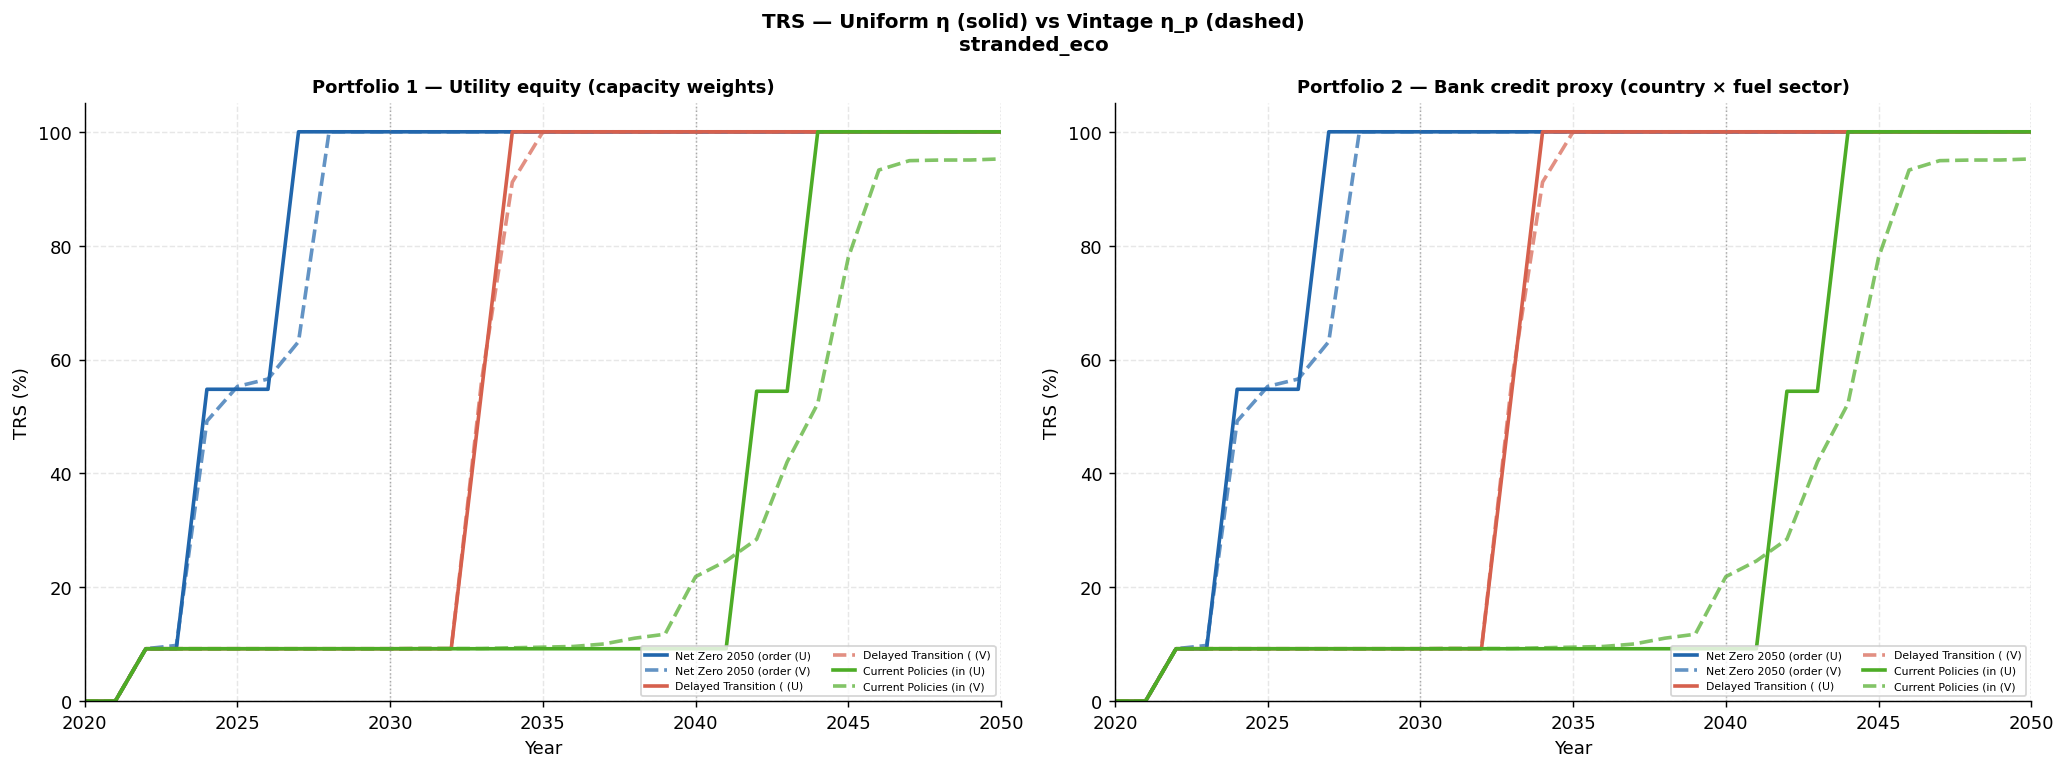

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (portfolio, title) in zip(axes, port_configs):
    for scenario in SCENARIOS:
        for version, ls, alpha in [('uniform','-',1.0), ('vintage','--',0.7)]:
            trs = trs_results[(version, PRIMARY_STRANDING, portfolio)]
            sub = trs[trs['scenario'] == scenario].sort_values('year')
            ax.plot(sub['year'], sub['trs']*100,
                    color=SCENARIO_COLORS[scenario], linewidth=2,
                    linestyle=ls, alpha=alpha,
                    label=f"{SCENARIO_LABELS[scenario][:20]} ({'U' if version=='uniform' else 'V'})")
    for yr in HORIZONS:
        ax.axvline(yr, color='grey', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.set_xlabel('Year'); ax.set_ylabel('TRS (%)')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlim(2020, 2050); ax.set_ylim(0)
    ax.legend(fontsize=6, ncol=2)

fig.suptitle('TRS — Uniform η (solid) vs Vintage η_p (dashed)\n'
             f'{PRIMARY_STRANDING}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../../outputs/figures/fig_trs_uniform_vs_vintage.png', dpi=150, bbox_inches='tight')
plt.show()


## Task 7 — Sensitivity Analysis and Robustness

Systematic sensitivity analysis on:
1. Carbon price (±20%)
2. Electricity price (±20%)
3. Technical lifetime (±5 years)
4. Stranding threshold K (1, 3, 5)
5. Stranding definition (eco vs rule-based vs utilisation)
6. η model (uniform vs vintage)

**Two output types per parameter:**
- EU aggregate stranded share at **each user-defined HORIZON** under Net Zero 2050
- **Country ranking stability**: does the top-N ranking change under perturbation?

**Design note:** Sensitivity is measured across all HORIZONS (not just 2050) to avoid
the ceiling effect — at 2050/Net Zero 2050 the baseline is already 100%, making
price perturbations uninformative. The tornado chart uses max |Δ| across all HORIZONS
to capture the most informative signal for each parameter.

---

In [45]:
SENS_SCENARIO = 'Delayed transition'

# Reference horizon for country ranking: first HORIZON with meaningful dispersion
# (stranded_eco NZ2050 = 100% at 2030 already, so we use rule-based at first horizon
#  for ranking — or simply HORIZONS[0] for consistency)
RANK_HOR = HORIZONS[0]  # 2030 — most dispersion in rule-based and cross-scenario

def eu_share_at(df_s, defn, scenario, year):
    sub = df_s[(df_s['scenario']==scenario) & (df_s['year']==year)]
    if len(sub) == 0: return np.nan
    return np.average(sub[defn], weights=sub['capacity_mw'])

def country_ranking_at(df_s, defn, scenario, year, n=TOP_N_COUNTRIES):
    """Returns ordered list of top-N countries by stranded share."""
    agg = AGG_from_df(df_s, defn)
    sub = agg['overall'][(agg['overall']['scenario']==scenario) & (agg['overall']['year']==year)]
    return sub.nlargest(n, 'stranded_share')['country'].tolist()

def AGG_from_df(df_s, defn):
    """Lightweight aggregation for sensitivity runs."""
    overall = (
        df_s.groupby(['country','scenario','year'])
        .apply(lambda x: pd.Series({
            'stranded_cap_mw': (x[defn] * x['capacity_mw']).sum(),
            'total_cap_mw'   : x['capacity_mw'].sum(),
        }))
        .reset_index()
    )
    overall['stranded_share'] = (overall['stranded_cap_mw'] / overall['total_cap_mw']).fillna(0)
    return {'overall': overall}

# Baseline: dict {horizon → share%} across all HORIZONS
baseline_shares = {
    h: eu_share_at(df_u, 'stranded_eco', SENS_SCENARIO, h) * 100
    for h in HORIZONS
}
baseline_rank = country_ranking_at(df_u, 'stranded_eco', SENS_SCENARIO, RANK_HOR)

print(f"Sensitivity scenario: {SENS_SCENARIO}")
print(f"Baseline EU stranded share (stranded_eco, uniform) at each HORIZON:")
for h, v in baseline_shares.items():
    print(f"  {h}: {v:.1f}%")
print(f"\nBaseline country ranking at {RANK_HOR} (top {TOP_N_COUNTRIES}): {baseline_rank}")

Sensitivity scenario: Delayed transition
Baseline EU stranded share (stranded_eco, uniform) at each HORIZON:
  2030: 9.2%
  2040: 100.0%
  2050: 100.0%

Baseline country ranking at 2030 (top 10): ['EST', 'HRV', 'CYP', 'SWE', 'FRA', 'FIN', 'IRL', 'ITA', 'ESP', 'DNK']


In [46]:
sens_records = []

def add_sens(param, variant, df_tmp, defn='stranded_eco'):
    """
    Record sensitivity result across ALL HORIZONS.
    max_abs_delta = max |Δ| across horizons → used for tornado chart.
    """
    shares = {h: eu_share_at(df_tmp, defn, SENS_SCENARIO, h) * 100 for h in HORIZONS}
    deltas = {h: round(shares[h] - baseline_shares[h], 1) for h in HORIZONS}
    max_abs_delta = max(abs(d) for d in deltas.values())

    rank         = country_ranking_at(df_tmp, defn, SENS_SCENARIO, RANK_HOR)
    rank_changes = sum(1 for i, c in enumerate(rank)
                       if i < len(baseline_rank) and c != baseline_rank[i])

    record = {
        'Parameter'           : param,
        'Variant'             : variant,
        'Max |Δ| (pp)'        : round(max_abs_delta, 1),
        'Rank changes (top N)': rank_changes,
        'Ranking'             : rank[:5],
    }
    for h in HORIZONS:
        record[f'Share {h} (%)'] = round(shares[h], 1)
        record[f'Δ {h} (pp)']    = deltas[h]
    sens_records.append(record)

# ── 1. Carbon price ±20% ──────────────────────────────────────────
metrics_idx = metrics_u.set_index('gppd_idnr')
for mult, label in [(0.8, 'Carbon ×0.8'), (1.0, 'Baseline'), (1.2, 'Carbon ×1.2')]:
    df_tmp = df_u.copy()
    df_tmp['margin_adj'] = df_tmp.apply(
        lambda r: r['margin'] + (1 - mult) * carbon_price.get((r['scenario'], r['year']), 0)
                                          * metrics_idx.loc[r['gppd_idnr'],
                                                            'carbon_intensity_tCO2_per_MWh_elec']
        if pd.notna(r['margin']) else np.nan, axis=1
    )
    df_tmp['neg_margin'] = (df_tmp['margin_adj'] < 0).astype(float)
    df_tmp['neg_margin'] = df_tmp['neg_margin'].where(df_tmp['margin_adj'].notna(), np.nan)
    df_tmp['_cn'] = df_tmp.groupby(['gppd_idnr','scenario'])['neg_margin'].transform(
        lambda x: x.rolling(K, min_periods=K).sum())
    df_tmp['_raw'] = (df_tmp['_cn'] == K).astype(int)
    df_tmp['stranded_eco'] = df_tmp.groupby(['gppd_idnr','scenario'])['_raw'].transform(
        lambda x: x.cummax()).astype(int)
    add_sens('Carbon price', label, df_tmp)
print("Carbon price sensitivity done.")

# ── 2. Electricity price ±20% ────────────────────────────────────
for mult, label in [(0.8, 'Elec ×0.8'), (1.0, 'Baseline'), (1.2, 'Elec ×1.2')]:
    df_tmp = df_u.copy()
    df_tmp['margin_adj'] = df_tmp.apply(
        lambda r: r['margin'] + (mult - 1) * elec_price.get((r['scenario'], r['year']), 0)
        if pd.notna(r['margin']) else np.nan, axis=1
    )
    df_tmp['neg_margin'] = (df_tmp['margin_adj'] < 0).astype(float)
    df_tmp['neg_margin'] = df_tmp['neg_margin'].where(df_tmp['margin_adj'].notna(), np.nan)
    df_tmp['_cn'] = df_tmp.groupby(['gppd_idnr','scenario'])['neg_margin'].transform(
        lambda x: x.rolling(K, min_periods=K).sum())
    df_tmp['_raw'] = (df_tmp['_cn'] == K).astype(int)
    df_tmp['stranded_eco'] = df_tmp.groupby(['gppd_idnr','scenario'])['_raw'].transform(
        lambda x: x.cummax()).astype(int)
    add_sens('Electricity price', label, df_tmp)
print("Electricity price sensitivity done.")

# ── 3. Technical lifetime ±5 years ───────────────────────────────
# Note: perturbs the rule-based committed-emissions stranding
# by changing the integration horizon min(2050, comm + lt ± delta)
# Approximated here via stranded_rb flag recomputation on df_u
for delta, label in [(-5, 'Lifetime -5yr'), (0, 'Baseline'), (+5, 'Lifetime +5yr')]:
    df_tmp = df_u.copy()
    df_tmp['stranded_rb'] = (
        df_tmp['year'] > df_tmp['commissioning_year'] + df_tmp['lifetime'] + delta
    ).astype(int)
    add_sens('Technical lifetime', label, df_tmp, defn='stranded_rb')
print("Lifetime sensitivity done.")

# ── 4. K threshold ───────────────────────────────────────────────
for K_val, label in [(1,'K=1'), (3,'K=3 (baseline)'), (5,'K=5')]:
    df_tmp = df_u.copy()
    df_tmp['neg_margin'] = (df_tmp['margin'] < 0).astype(float)
    df_tmp['neg_margin'] = df_tmp['neg_margin'].where(df_tmp['margin'].notna(), np.nan)
    df_tmp['_cn'] = df_tmp.groupby(['gppd_idnr','scenario'])['neg_margin'].transform(
        lambda x: x.rolling(K_val, min_periods=K_val).sum())
    df_tmp['_raw'] = (df_tmp['_cn'] == K_val).astype(int)
    df_tmp['stranded_eco'] = df_tmp.groupby(['gppd_idnr','scenario'])['_raw'].transform(
        lambda x: x.cummax()).astype(int)
    add_sens('Threshold K', label, df_tmp)
print("K threshold sensitivity done.")

# ── 5. Stranding definition ──────────────────────────────────────
for defn, label in [
    ('stranded_eco',  'Economic K=3'),
    ('stranded_rb',   'Rule-based'),
    ('stranded_util', 'Utilisation CF<10%'),
]:
    add_sens('Stranding definition', label, df_u, defn=defn)
print("Stranding definition sensitivity done.")

# ── 6. η model ───────────────────────────────────────────────────
for df_s, label in [(df_u, 'Uniform η'), (df_v, 'Vintage η_p')]:
    shares = {h: eu_share_at(df_s, 'stranded_eco', SENS_SCENARIO, h)*100 for h in HORIZONS}
    deltas = {h: round(shares[h] - baseline_shares[h], 1) for h in HORIZONS}
    max_abs_delta = max(abs(d) for d in deltas.values())
    rank = country_ranking_at(df_s, 'stranded_eco', SENS_SCENARIO, RANK_HOR)
    rank_changes = sum(1 for i, c in enumerate(rank)
                       if i < len(baseline_rank) and c != baseline_rank[i])
    record = {
        'Parameter': 'η model', 'Variant': label,
        'Max |Δ| (pp)': round(max_abs_delta, 1),
        'Rank changes (top N)': rank_changes,
        'Ranking': rank[:5],
    }
    for h in HORIZONS:
        record[f'Share {h} (%)'] = round(shares[h], 1)
        record[f'Δ {h} (pp)']    = deltas[h]
    sens_records.append(record)
print("η model sensitivity done.")

df_sens = pd.DataFrame(sens_records)
df_sens.to_csv('../../data/processed/sensitivity_table.csv', index=False)

# Display key columns
display_cols = ['Parameter','Variant','Max |Δ| (pp)','Rank changes (top N)'] + \
               [f'Δ {h} (pp)' for h in HORIZONS]
display(df_sens[display_cols])

Carbon price sensitivity done.
Electricity price sensitivity done.
Lifetime sensitivity done.
K threshold sensitivity done.
Stranding definition sensitivity done.
η model sensitivity done.


,Parameter,Variant,Max |Δ| (pp),Rank changes (top N),Δ 2030 (pp),Δ 2040 (pp),Δ 2050 (pp)
0,Carbon price,Carbon ×0.8,0.000,0,0.000,0.000,0.000
1,Carbon price,Baseline,0.000,0,0.000,0.000,0.000
2,Carbon price,Carbon ×1.2,0.000,0,0.000,0.000,0.000
3,Electricity price,Elec ×0.8,0.000,0,0.000,0.000,0.000
4,Electricity price,Baseline,0.000,0,0.000,0.000,0.000
5,Electricity price,Elec ×1.2,0.000,0,0.000,0.000,0.000
6,Technical lifetime,Lifetime -5yr,46.700,10,46.700,-12.700,-2.300
7,Technical lifetime,Baseline,37.700,10,37.700,-24.200,-4.300
8,Technical lifetime,Lifetime +5yr,44.100,10,24.800,-44.100,-12.700
9,Threshold K,K=1,0.000,0,0.000,0.000,0.000


### 7.1 Tornado chart — max impact on EU stranded share across all HORIZONS

The tornado uses **max |Δ| across all user-defined HORIZONS** to avoid the ceiling
effect at 2050 (where baseline = 100% under Net Zero 2050). This captures the
most informative signal for each parameter across the full projection period.

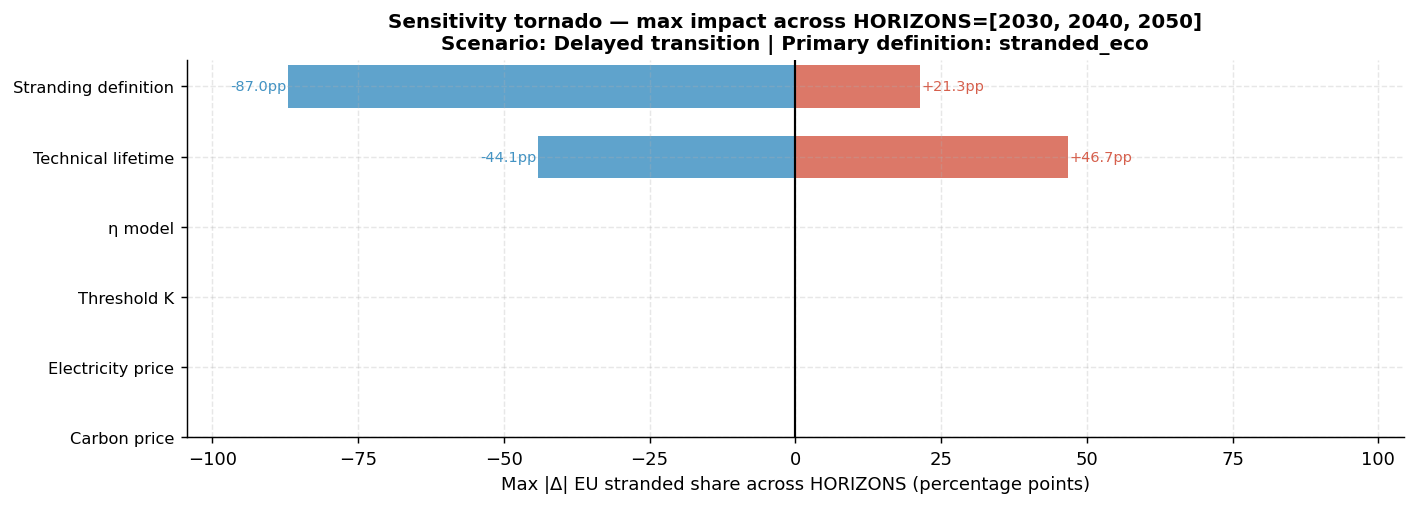

In [47]:
# Tornado: max |Δ| across all HORIZONS per parameter
tornado = (
    df_sens.groupby('Parameter')['Max |Δ| (pp)']
    .max()
    .sort_values()
)

# Also compute signed min/max for bar direction
delta_cols = [f'Δ {h} (pp)' for h in HORIZONS]
tornado_signed = df_sens.groupby('Parameter')[delta_cols].apply(
    lambda x: pd.Series({
        'delta_min': x.values.min(),
        'delta_max': x.values.max(),
    })
)
tornado_signed['abs_range'] = tornado_signed['delta_max'] - tornado_signed['delta_min']
tornado_signed = tornado_signed.sort_values('abs_range')

fig, ax = plt.subplots(figsize=(11, 4))
y_pos = np.arange(len(tornado_signed))

for i, (param, row) in enumerate(tornado_signed.iterrows()):
    if row['delta_min'] < 0:
        ax.barh(i, row['delta_min'], left=0, color='#4393c3', alpha=0.85, height=0.6)
        ax.text(row['delta_min'] - 0.3, i, f"{row['delta_min']:+.1f}pp",
                va='center', ha='right', fontsize=8, color='#4393c3')
    if row['delta_max'] > 0:
        ax.barh(i, row['delta_max'], left=0, color='#d6604d', alpha=0.85, height=0.6)
        ax.text(row['delta_max'] + 0.3, i, f"{row['delta_max']:+.1f}pp",
                va='center', ha='left', fontsize=8, color='#d6604d')

ax.set_yticks(y_pos)
ax.set_yticklabels(tornado_signed.index, fontsize=9)
ax.axvline(0, color='black', linewidth=1.2)
ax.set_xlabel('Max |Δ| EU stranded share across HORIZONS (percentage points)', fontsize=10)
ax.set_title(f'Sensitivity tornado — max impact across HORIZONS={HORIZONS}\n'
             f'Scenario: {SENS_SCENARIO} | Primary definition: {PRIMARY_STRANDING}',
             fontsize=11, fontweight='bold')

x_lim = max(abs(tornado_signed['delta_min'].min()), tornado_signed['delta_max'].max())
ax.set_xlim(-x_lim*1.2, x_lim*1.2)
plt.tight_layout()
plt.savefig('../../outputs/figures/fig_sensitivity_tornado.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.2 Country ranking stability — does the ranking hold under perturbation?

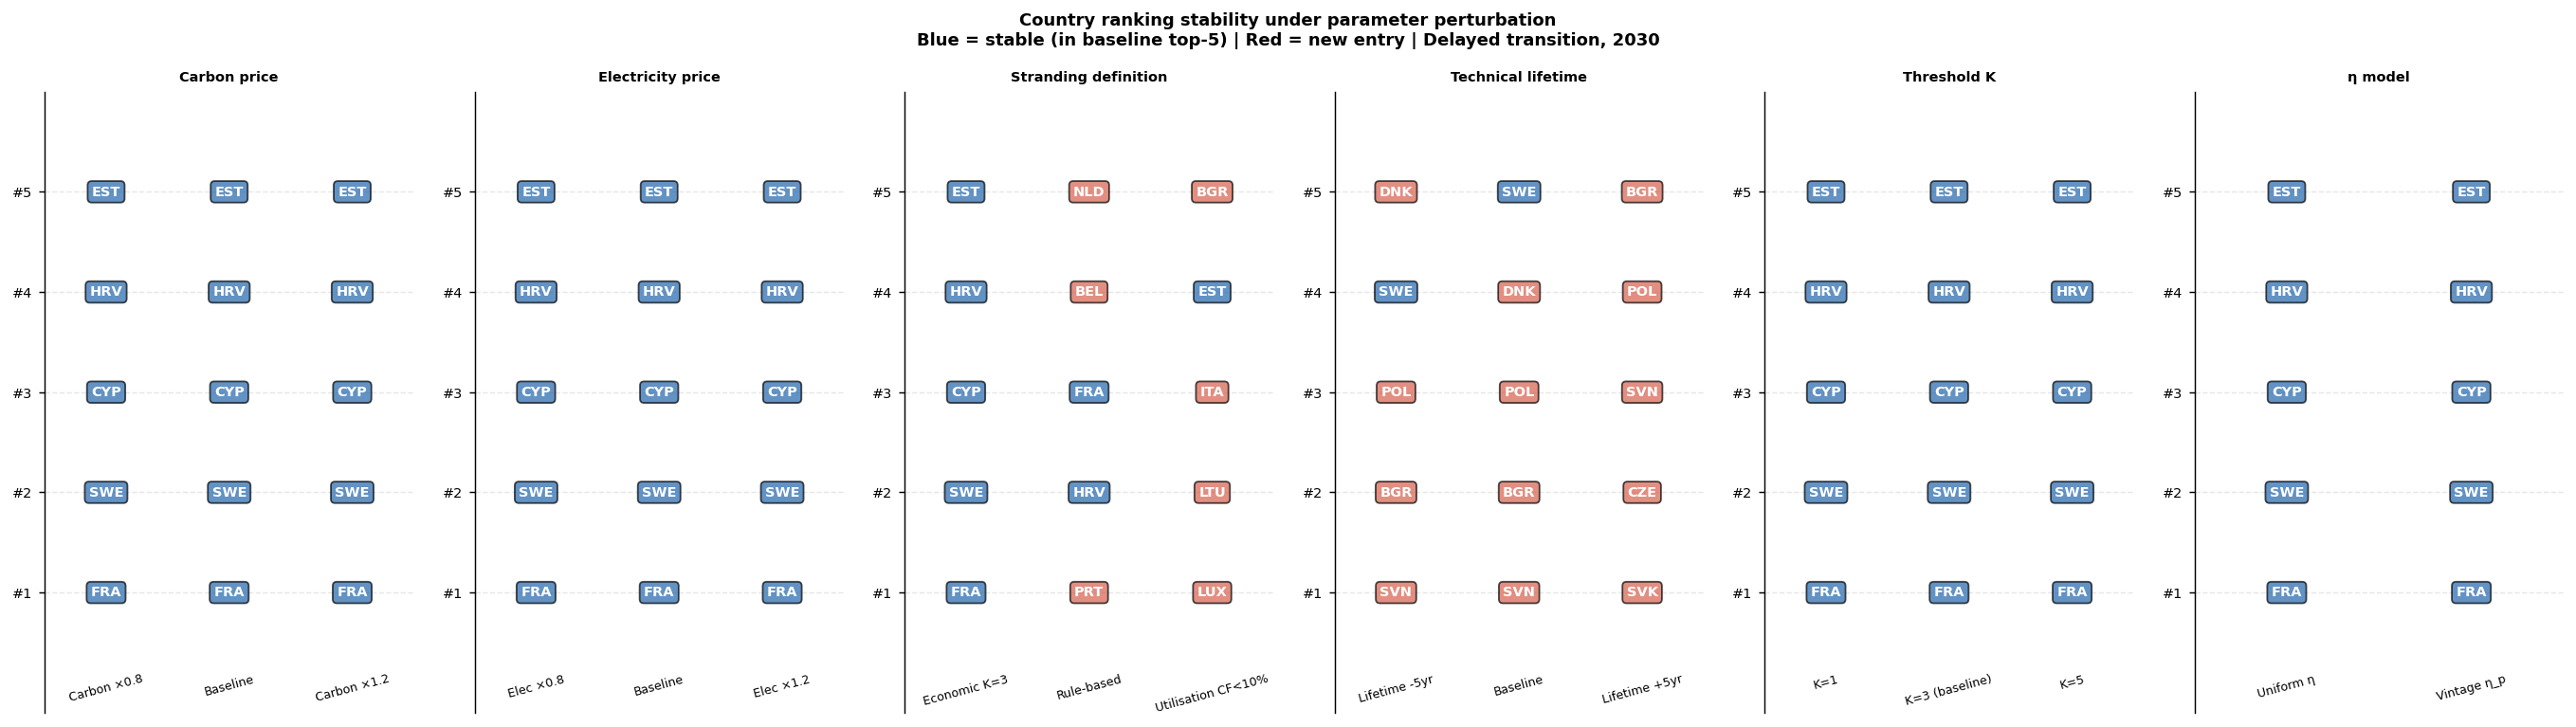

In [48]:
# For each parameter, show top-5 ranking under each variant
rank_data = df_sens[['Parameter','Variant','Ranking','Rank changes (top N)']].copy()

fig, axes = plt.subplots(1, len(df_sens['Parameter'].unique()),
                          figsize=(3.5*df_sens['Parameter'].nunique(), 6))

for ax, (param, grp) in zip(axes, df_sens.groupby('Parameter')):
    grp = grp.reset_index(drop=True)
    n_variants = len(grp)
    n_ranks    = min(5, TOP_N_COUNTRIES)

    for v_idx, (_, row) in enumerate(grp.iterrows()):
        ranking = row['Ranking'] if isinstance(row['Ranking'], list) else []
        for r_idx, country in enumerate(ranking[:n_ranks]):
            color = '#d6604d' if country not in baseline_rank[:n_ranks] else '#2166ac'
            ax.text(v_idx, n_ranks - r_idx - 1, country,
                    ha='center', va='center', fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.7),
                    color='white', fontweight='bold')
        ax.text(v_idx, -0.8, row['Variant'], ha='center', va='top', fontsize=7, rotation=15)

    ax.set_xlim(-0.5, n_variants - 0.5)
    ax.set_ylim(-1.2, n_ranks)
    ax.set_yticks(range(n_ranks))
    ax.set_yticklabels([f'#{i+1}' for i in range(n_ranks)], fontsize=8)
    ax.set_title(param, fontsize=8, fontweight='bold')
    ax.set_xticks([])
    ax.spines['bottom'].set_visible(False)

fig.suptitle(f'Country ranking stability under parameter perturbation\n'
             f'Blue = stable (in baseline top-5) | Red = new entry | {SENS_SCENARIO}, {RANK_HOR}',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('../../outputs/figures/fig_ranking_stability.png', dpi=150, bbox_inches='tight')
plt.show()


### 7.3 Multi-scenario robustness — EU stranded share across all scenarios

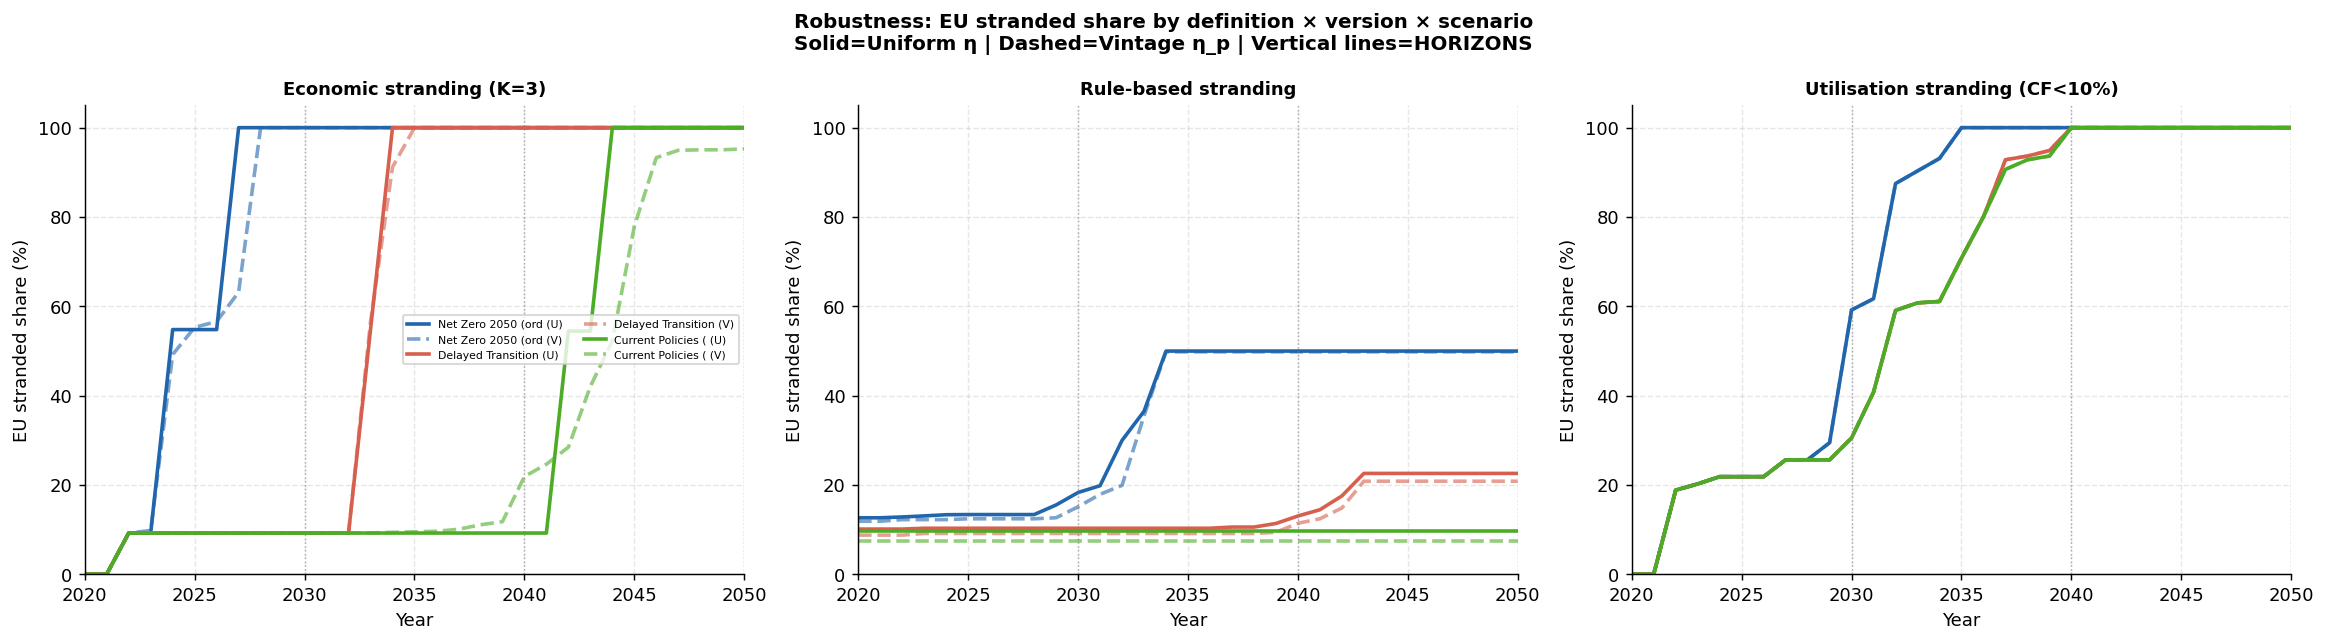

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, defn, title in zip(axes,
    ['stranded_eco', 'stranded_rb', 'stranded_util'],
    ['Economic stranding (K=3)', 'Rule-based stranding', 'Utilisation stranding (CF<10%)']):

    for scenario in SCENARIOS:
        for version, df_s, ls in [('uniform', df_u, '-'), ('vintage', df_v, '--')]:
            ts = eu_share_timeseries(df_s, defn)
            sub = ts[ts['scenario'] == scenario]
            label = f"{SCENARIO_LABELS[scenario][:18]} ({'U' if version=='uniform' else 'V'})"
            ax.plot(sub['year'], sub['share']*100,
                    color=SCENARIO_COLORS[scenario], linestyle=ls, linewidth=2,
                    alpha=1.0 if version == 'uniform' else 0.6, label=label)

    for yr in HORIZONS:
        ax.axvline(yr, color='grey', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Year'); ax.set_ylabel('EU stranded share (%)')
    ax.set_xlim(2020, 2050); ax.set_ylim(0, 105)

axes[0].legend(fontsize=6, ncol=2)
fig.suptitle('Robustness: EU stranded share by definition × version × scenario\n'
             'Solid=Uniform η | Dashed=Vintage η_p | Vertical lines=HORIZONS',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../../outputs/figures/fig_robustness_all.png', dpi=150, bbox_inches='tight')
plt.show()


### 7.4 CF threshold sensitivity for utilisation stranding

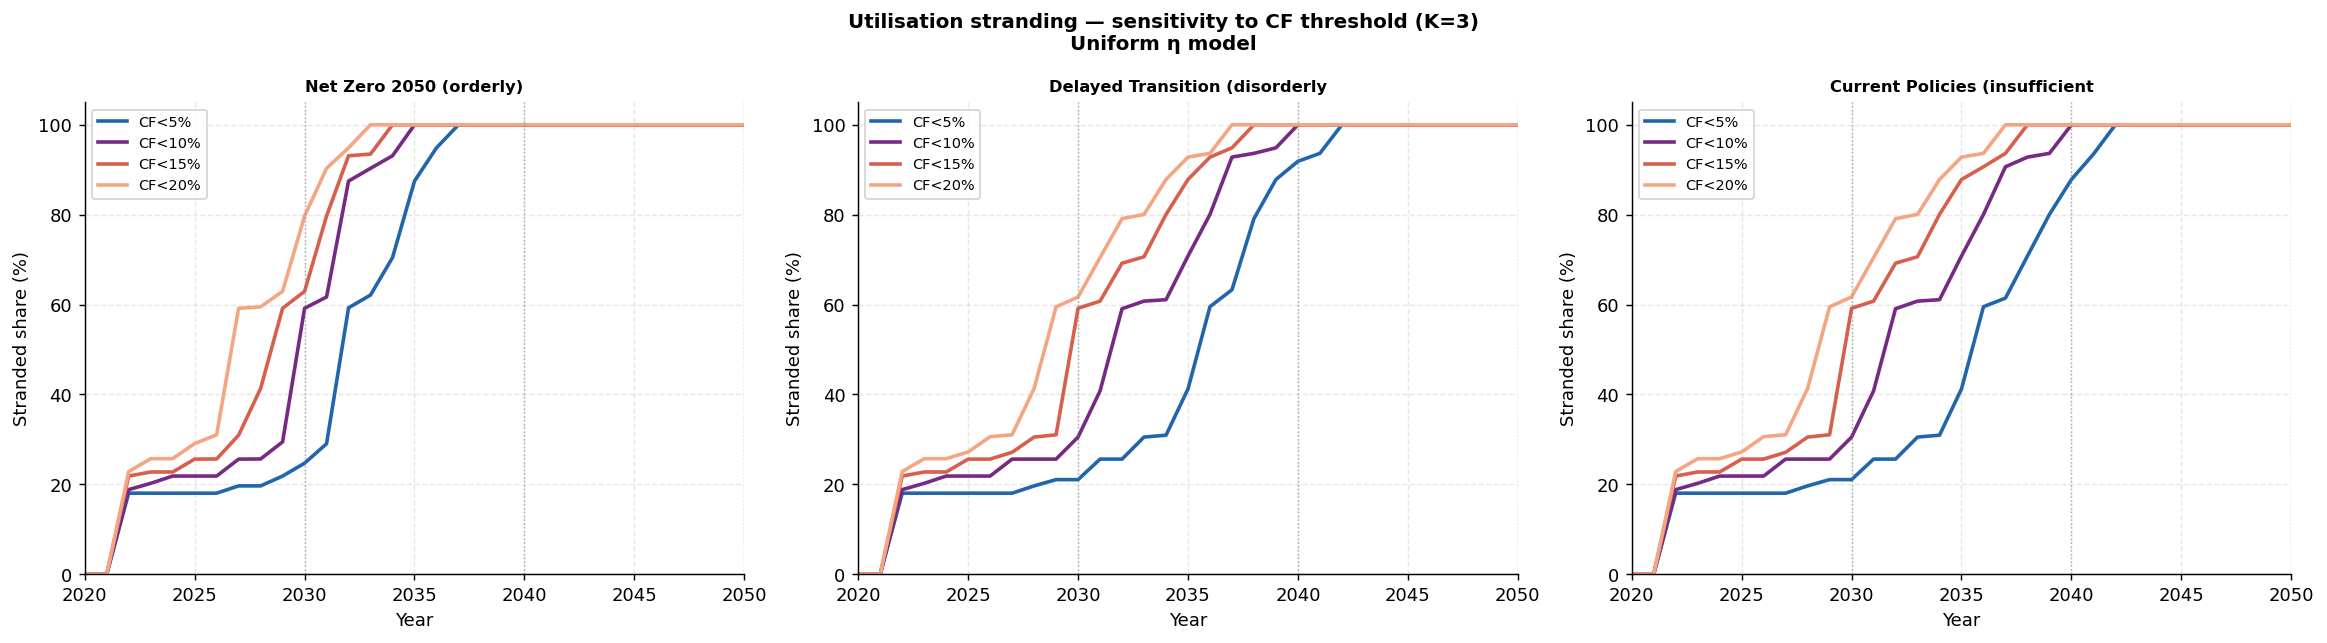

In [50]:
thresholds  = [0.05, 0.10, 0.15, 0.20]
thresh_colors = ['#2166ac','#762a83','#d6604d','#f4a582']

fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(6*len(SCENARIOS), 5))

for ax, scenario in zip(axes, SCENARIOS):
    for thresh, color in zip(thresholds, thresh_colors):
        df_tmp = df_u.copy()
        df_tmp['_lc'] = (df_tmp['cf_t'] < thresh).astype(float)
        df_tmp['_cc'] = df_tmp.groupby(['gppd_idnr','scenario'])['_lc'].transform(
            lambda x: x.rolling(K, min_periods=K).sum())
        df_tmp['_ur'] = (df_tmp['_cc'] == K).astype(int)
        df_tmp['stranded_util_t'] = df_tmp.groupby(['gppd_idnr','scenario'])['_ur'].transform(
            lambda x: x.cummax()).astype(int)
        ts = eu_share_timeseries(df_tmp, 'stranded_util_t')
        sub = ts[ts['scenario'] == scenario]
        ax.plot(sub['year'], sub['share']*100, color=color, linewidth=2,
                label=f'CF<{thresh*100:.0f}%')
    for yr in HORIZONS:
        ax.axvline(yr, color='grey', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.set_title(SCENARIO_LABELS[scenario][:30], fontsize=9, fontweight='bold')
    ax.set_xlabel('Year'); ax.set_ylabel('Stranded share (%)')
    ax.set_xlim(2020, 2050); ax.set_ylim(0, 105)
    ax.legend(fontsize=8)

fig.suptitle(f'Utilisation stranding — sensitivity to CF threshold (K={K})\n'
             'Uniform η model',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../../outputs/figures/fig_cf_threshold_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()


### 7.5 Final summary — dominant drivers of EU stranded share

Sensitivity summary — Delayed transition | HORIZONS=[2030, 2040, 2050]
Baseline shares: {2030: '9.2%', 2040: '100.0%', 2050: '100.0%'}



,Parameter,Variant,Max |Δ| (pp),Rank changes (top N),Share 2030 (%),Share 2040 (%),Share 2050 (%),Δ 2030 (pp),Δ 2040 (pp),Δ 2050 (pp)
0,Stranding definition,Rule-based,87.000,9,10.300,13.000,22.600,1.100,-87.000,-77.400
1,Technical lifetime,Lifetime -5yr,46.700,10,55.900,87.300,97.700,46.700,-12.700,-2.300
2,Technical lifetime,Lifetime +5yr,44.100,10,34.100,55.900,87.300,24.800,-44.100,-12.700
3,Technical lifetime,Baseline,37.700,10,46.900,75.800,95.700,37.700,-24.200,-4.300
4,Stranding definition,Utilisation CF<10%,21.300,10,30.500,100.000,100.000,21.300,0.000,0.000
5,Threshold K,K=3 (baseline),0.000,0,9.200,100.000,100.000,0.000,0.000,0.000
6,η model,Uniform η,0.000,0,9.200,100.000,100.000,0.000,0.000,0.000
7,Stranding definition,Economic K=3,0.000,0,9.200,100.000,100.000,0.000,0.000,0.000
8,Threshold K,K=5,0.000,0,9.200,100.000,100.000,0.000,0.000,0.000
9,Carbon price,Carbon ×0.8,0.000,0,9.200,100.000,100.000,0.000,0.000,0.000


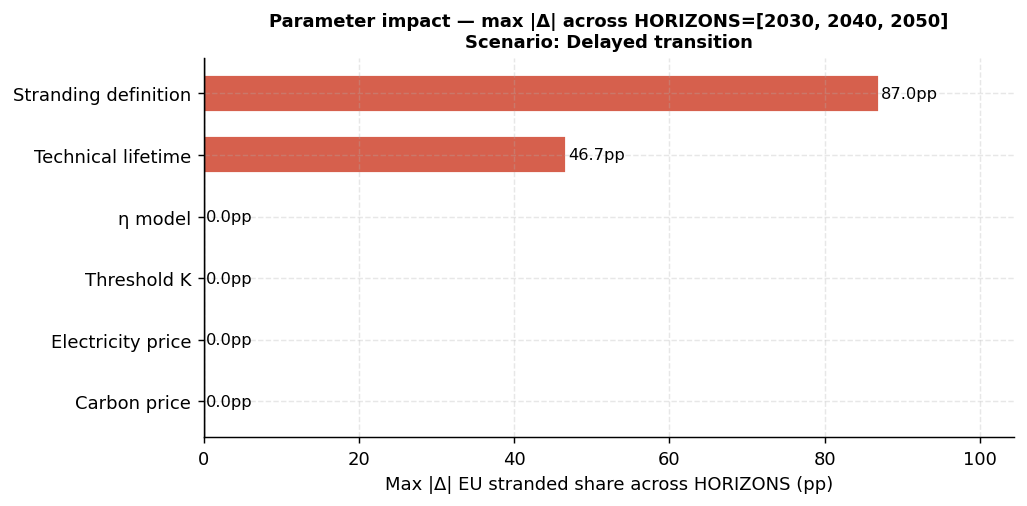

In [51]:
# Summary table sorted by max |Δ|
summary = df_sens[
    ['Parameter','Variant','Max |Δ| (pp)','Rank changes (top N)'] +
    [f'Share {h} (%)' for h in HORIZONS] +
    [f'Δ {h} (pp)' for h in HORIZONS]
].copy().sort_values('Max |Δ| (pp)', ascending=False).reset_index(drop=True)

print(f"Sensitivity summary — {SENS_SCENARIO} | HORIZONS={HORIZONS}")
print(f"Baseline shares: { {h: f'{v:.1f}%' for h,v in baseline_shares.items()} }\n")
display(summary)

# Bar chart — max |Δ| per parameter
param_impact = df_sens.groupby('Parameter')['Max |Δ| (pp)'].max().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors_bar = ['#d6604d' if v > 5 else '#fdae61' if v > 2 else '#abd9e9'
              for v in param_impact.values]
ax.barh(param_impact.index, param_impact.values, color=colors_bar,
        edgecolor='white', height=0.6)
ax.set_xlabel('Max |Δ| EU stranded share across HORIZONS (pp)', fontsize=10)
ax.set_title(f'Parameter impact — max |Δ| across HORIZONS={HORIZONS}\n'
             f'Scenario: {SENS_SCENARIO}',
             fontsize=10, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
for i, (param, val) in enumerate(param_impact.items()):
    ax.text(val + 0.2, i, f'{val:.1f}pp', va='center', fontsize=9)
ax.set_xlim(0, param_impact.max() * 1.2)
plt.tight_layout()
plt.savefig('../../outputs/figures/fig_sensitivity_impact_bar.png', dpi=150, bbox_inches='tight')
plt.show()